#  Cardiac Patient Monitoring System
### Heart Disease Prediction — Exploratory Data Analysis & Machine Learning

---

## Project Overview

This notebook applies a full supervised machine learning pipeline to predict whether a patient has heart disease based on clinical measurements.

The dataset combines records from five public heart disease registries and contains 918 patient observations across 11 features and one binary target variable.

**Source:** Heart Failure Prediction Dataset — Kaggle (Cleveland, Hungarian, Switzerland, Long Beach VA, and Stalog registries combined)

**Task type:** Binary classification (`HeartDisease`: 0 = no disease, 1 = disease)

---

## Data Dictionary

| Feature | Type | Description |
|---|---|---|
| `Age` | Numeric | Patient age in years |
| `Sex` | Categorical | `M` = Male, `F` = Female |
| `ChestPainType` | Categorical | `ATA` Atypical Angina, `NAP` Non-Anginal Pain, `ASY` Asymptomatic, `TA` Typical Angina |
| `RestingBP` | Numeric | Resting blood pressure (mm Hg) |
| `Cholesterol` | Numeric | Serum cholesterol (mg/dl) |
| `FastingBS` | Binary | `1` if fasting blood sugar > 120 mg/dl, `0` otherwise |
| `RestingECG` | Categorical | `Normal`, `ST` wave abnormality, `LVH` left ventricular hypertrophy |
| `MaxHR` | Numeric | Maximum heart rate achieved (bpm) |
| `ExerciseAngina` | Categorical | Exercise-induced angina: `Y` = Yes, `N` = No |
| `Oldpeak` | Numeric | ST depression induced by exercise relative to rest |
| `ST_Slope` | Categorical | Slope of peak exercise ST segment: `Up`, `Flat`, `Down` |
| `HeartDisease` | **Target** | `1` = heart disease present, `0` = no heart disease |

---

## Notebook Structure

1. Loading the Dataset
2. Understanding the Dataset Structure
3. Univariate Analysis — Categorical Features
4. Univariate Analysis — Numerical Features
5. Target Variable Analysis
6. Feature vs Target Analysis
7. Correlation Analysis
8. Data Quality and Preparation
9. Machine Learning Pipeline
   - 9.1 Defining Features and Target
   - 9.2 Feature Engineering
   - 9.3 Train / Validation / Test Split
   - 9.4 Preprocessing Pipeline
   - 9.5 Baseline — Logistic Regression
   - 9.6 Model Comparison
   - 9.7 Hyperparameter Tuning — GridSearchCV
   - 9.8 Final Evaluation — Test Set

10. Project Summary

## 1. Loading the Dataset

The first step is to load the dataset and verify that it was read correctly. I will also set up the libraries and global configuration used throughout this notebook.

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score
)

# Reproducibility seed — used for all train/test splits and model training
SEED = 42

# Display all columns when printing DataFrames
pd.set_option("display.max_columns", None)

In [2]:
# Load the dataset
DATA_PATH = "Data/heart.csv"
df = pd.read_csv(DATA_PATH)

# Display the first five rows to confirm successful loading
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


### Inspecting the Dataset Dimensions

The first five rows confirm the dataset loaded correctly. Before examining features in detail, I will check the overall dimensions to understand how many observations and columns are available.

---

In [3]:
# Get the number of rows and columns in the dataset
df.shape

(918, 12)

**Observation**

The dataset contains **918 observations** and **12 columns** — 11 features and one target variable (`HeartDisease`). The size is sufficient for supervised learning.

---

## 2. Understanding the Dataset Structure

With the dimensions confirmed, I will now inspect the column names, data types, and non-null counts to understand the structure before exploring individual features.

In [4]:
# Inspect the DataFrame structure, including column names, data types,
# and the number of non-null values in each column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


**Observation**

The dataset contains 12 columns with 918 observations. All columns currently
contain 918 non-null values, so there are no explicit missing values reported
by the DataFrame structure.

The dataset contains one `float64` column, six `int64` columns, and five string
columns. The string columns appear to represent categorical information, while
the numerical columns require further investigation before their roles are
defined.

The data types alone are not sufficient to determine the semantic role of each
feature. Therefore, the next step is to inspect the unique values and
distributions of the columns.

---

### Identifying Feature Types

The `info()` output shows five columns stored as strings — these are the categorical features. I will identify them explicitly so they can be treated separately from numerical features throughout the analysis.

In [5]:
# Identify columns stored as string values
categorical_columns = df.select_dtypes(include="str").columns

# Display the names of the categorical columns
categorical_columns

Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='str')

---

## 3. Univariate Analysis — Categorical Features

I will examine each categorical feature individually: its unique categories, frequency distribution, and any imbalance between categories.

**Exploring the `Sex` Feature**

The `Sex` column was identified as a categorical feature based on its data
type. I will now inspect the values present in this column and count how many
observations belong to each category.

In [6]:
# Count the number of observations in each category of the Sex feature
sex_counts = df["Sex"].value_counts()

sex_counts

Sex
M    725
F    193
Name: count, dtype: int64

**Visualizing the `Sex` Distribution**

The frequency counts show that the two categories are not equally represented
in the dataset. I will visualize the distribution to make this difference
easier to interpret.

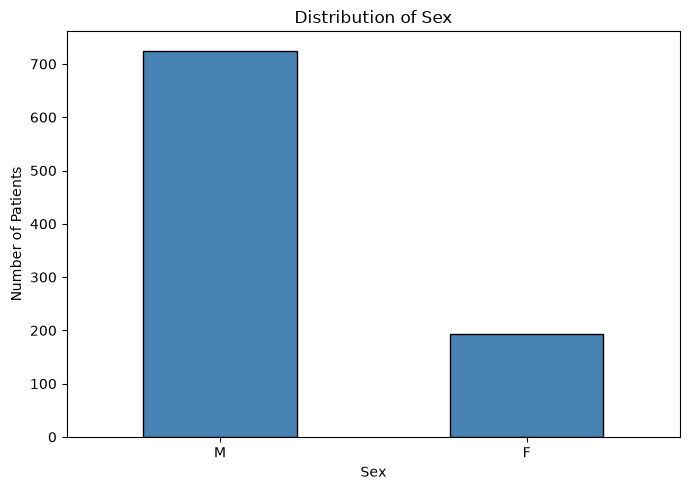

In [7]:
# Create a bar chart showing the number of observations in each Sex category
plt.figure(figsize=(7, 5))

sex_counts.plot(kind="bar", color="steelblue", edgecolor="black")

plt.title("Distribution of Sex")
plt.xlabel("Sex")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---

**Exploring the `ChestPainType` Feature**

The `ChestPainType` feature represents the type of chest pain reported for each
observation. I will inspect the categories present in the dataset and count
how frequently each category occurs.

In [8]:
# Count the number of observations in each chest pain category
chest_pain_counts = df["ChestPainType"].value_counts()

# Display the category frequencies
chest_pain_counts

ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

**Visualizing Chest Pain Types**

The frequency counts show that the four chest pain categories are not equally
represented in the dataset. I will visualize their distribution to compare the
relative number of observations in each category.

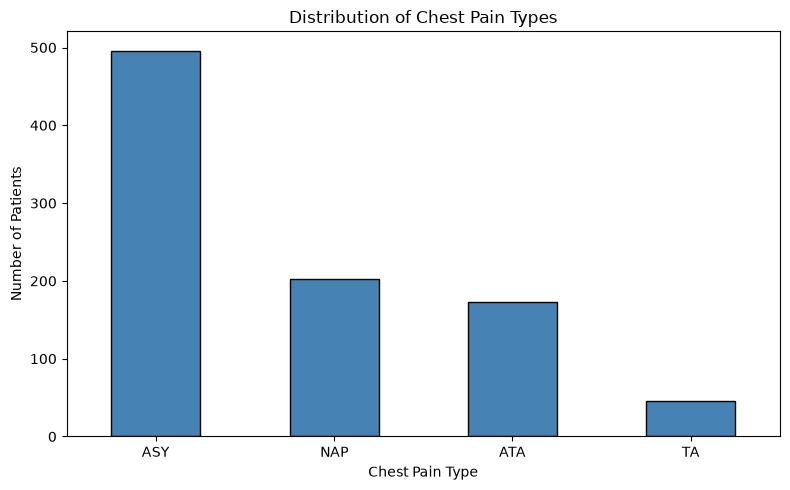

In [9]:
# Create a bar chart showing the frequency of each chest pain category
plt.figure(figsize=(8, 5))

chest_pain_counts.plot(kind="bar", color="steelblue", edgecolor="black")

plt.title("Distribution of Chest Pain Types")
plt.xlabel("Chest Pain Type")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation**
The dataset contains four chest pain categories: ASY, NAP, ATA, and TA.

ASY is the most frequent category with 496 observations, while TA is the least
frequent with 46 observations. This shows that the chest pain categories are
not evenly represented in the dataset.

At this stage, this describes only the distribution of the feature itself. It
does not tell us whether a specific chest pain type is associated with
`HeartDisease`. That relationship will be investigated later during the
exploratory analysis.

---

**Exploring the `RestingECG` Feature**

The `RestingECG` feature describes the resting electrocardiogram result for
each observation.

I will inspect the categories present in this feature and count the number of
observations belonging to each category.

In [10]:
# Count the number of observations in each resting ECG category
resting_ecg_counts = df["RestingECG"].value_counts()

# Display the category frequencies
resting_ecg_counts

RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

**Visualizing Resting ECG Categories**

The frequency counts show that the three resting ECG categories are not
equally represented in the dataset. I will visualize their distribution to
make the differences between the categories easier to compare.

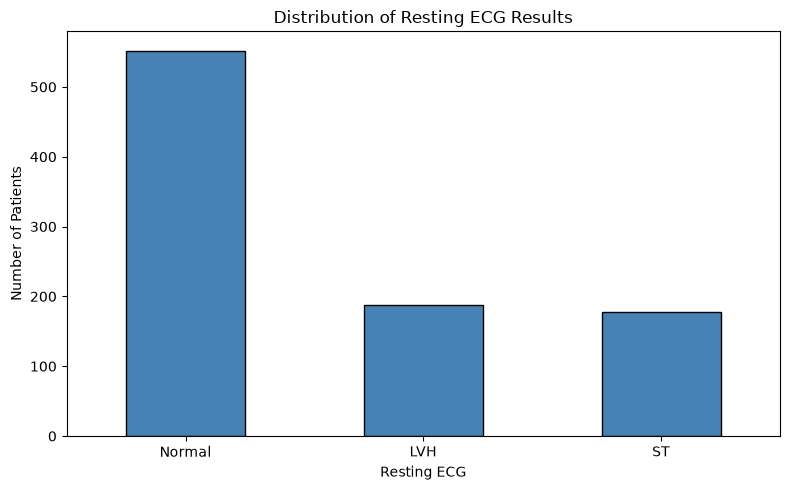

In [11]:
# Create a bar chart showing the frequency of each resting ECG category
plt.figure(figsize=(8, 5))

resting_ecg_counts.plot(kind="bar", color="steelblue", edgecolor="black")

plt.title("Distribution of Resting ECG Results")
plt.xlabel("Resting ECG")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---

**Exploring the `ExerciseAngina` Feature**

The `ExerciseAngina` feature indicates whether exercise-induced angina was
reported for an observation.

The feature uses categorical values representing whether angina occurred
during exercise. I will inspect the categories and count how frequently each
one occurs in the dataset.

In [12]:
# Count the number of observations in each ExerciseAngina category
exercise_angina_counts = df["ExerciseAngina"].value_counts()

# Display the category frequencies
exercise_angina_counts

ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

**Visualizing Exercise-Induced Angina**

The frequency counts show that the two categories are not equally represented
in the dataset. I will visualize the distribution to make the difference
between observations with and without exercise-induced angina easier to compare.

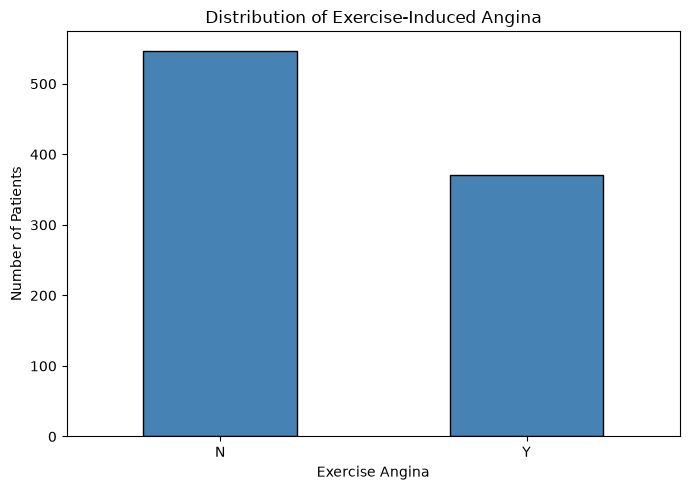

In [13]:
# Create a bar chart showing the frequency of each ExerciseAngina category
plt.figure(figsize=(7, 5))

exercise_angina_counts.plot(kind="bar", color="steelblue", edgecolor="black")

plt.title("Distribution of Exercise-Induced Angina")
plt.xlabel("Exercise Angina")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation**

The dataset contains 547 observations with no reported exercise-induced
angina and 371 observations with reported exercise-induced angina.

The two categories are therefore not equally represented, with the `N`
category being more frequent than the `Y` category.

This describes the distribution of the feature itself. The relationship
between exercise-induced angina and the `HeartDisease` target will be
investigated later.

---

**Exploring the `ST_Slope` Feature**

The `ST_Slope` feature describes the slope of the ST segment during peak
exercise.

Since this is a categorical feature, I will inspect the categories present in
the dataset and count how frequently each category occurs.

In [14]:
# Count the number of observations in each ST_Slope category
st_slope_counts = df["ST_Slope"].value_counts()

# Display the category frequencies
st_slope_counts

ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64

**Visualizing ST Slope Categories**

The frequency counts show that the three ST slope categories are not equally
represented in the dataset. I will visualize their distribution to compare the
number of observations in each category.

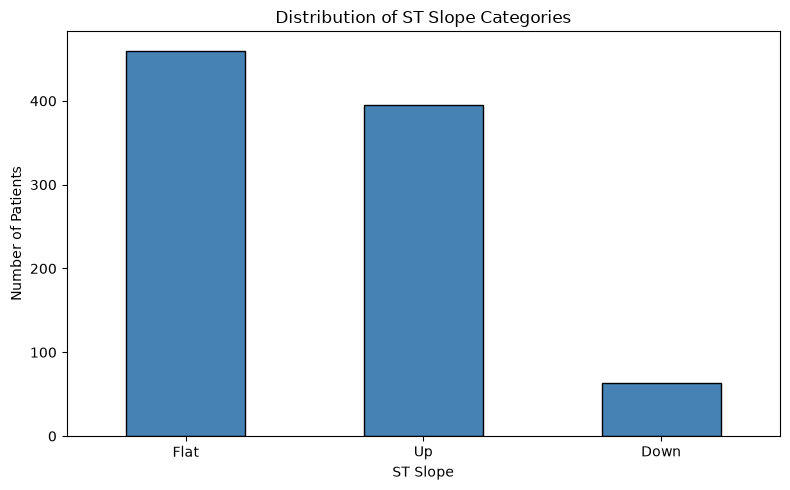

In [15]:
# Create a bar chart showing the frequency of each ST slope category
plt.figure(figsize=(8, 5))

st_slope_counts.plot(kind="bar", color="steelblue", edgecolor="black")

plt.title("Distribution of ST Slope Categories")
plt.xlabel("ST Slope")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation**

The dataset contains three ST slope categories: `Flat`, `Up`, and `Down`.

`Flat` is the most frequent category with 460 observations, followed by `Up`
with 395 observations. `Down` is the least frequent category with only 63
observations.

Therefore, the categories are not evenly represented in the dataset. The
relationship between ST slope and the `HeartDisease` target will be examined
later during exploratory analysis.

---

## 4. Univariate Analysis — Numerical Features

I will examine each numerical feature individually using descriptive statistics, histograms, and box plots to understand distributions and detect potential issues.

### Descriptive Statistics for Numerical Features

I will use descriptive statistics to get an initial overview of the numerical
features, including their central values, spread, and minimum and maximum
values.

In [16]:
# Generate descriptive statistics for the numerical columns
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


**Initial Observations**

The descriptive statistics provide an initial overview of the numerical
features. All numerical columns contain 918 observations.

The average age is approximately 53.5 years, while the median age is 54 years.
The mean and median are close, suggesting that the age distribution does not
appear to be strongly skewed based on these statistics alone.

Two suspicious minimum values were also identified: `RestingBP` has a minimum
of 0 and `Cholesterol` has a minimum of 0. These values require further
investigation because they may represent invalid measurements rather than
meaningful physiological values.

The `HeartDisease` variable contains only 0 and 1 values. Its mean is
approximately 0.553, which provides an initial indication that about 55% of
the observations belong to the class represented by 1.

These observations will be investigated further using visualizations and
additional data-quality checks.

---

**Understanding the `Age` Feature**

The `Age` feature represents the age of each observation in years.

I will use a histogram to examine how the ages are distributed across the
dataset.

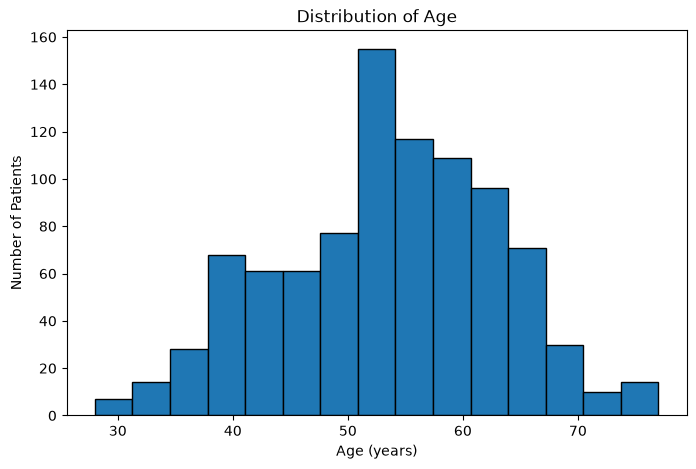

In [17]:
# Plot a histogram to visualize the distribution of patients' ages
plt.figure(figsize=(8, 5))

df["Age"].plot(kind="hist", bins=15, edgecolor="black")

# Add descriptive labels to the plot
plt.title("Distribution of Age")
plt.xlabel("Age (years)")
plt.ylabel("Number of Patients")

# Display the histogram
plt.show()

**Observation**

The histogram shows that the age distribution is concentrated around the
early to mid-50s, with the highest frequency appearing around this range.

This is consistent with the descriptive statistics, where the mean age is
approximately 53.5 years and the median age is 54 years.

The distribution does not appear to be dominated by a small number of extreme
values, although the full shape will be considered when analyzing the remaining
numerical features.

---

**Understanding the `RestingBP` Feature**

The `RestingBP` feature represents resting blood pressure measurements
recorded for each observation.

I will use a histogram to examine the distribution of resting blood pressure
values and identify any unusual patterns that may require further investigation.

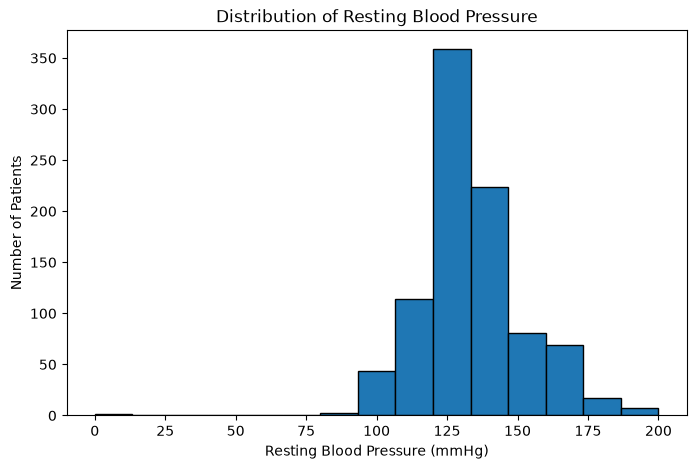

In [18]:
# Plot a histogram to visualize the distribution of resting blood pressure
plt.figure(figsize=(8, 5))

df["RestingBP"].plot(kind="hist", bins=15, edgecolor="black")

# Add descriptive labels to the plot
plt.title("Distribution of Resting Blood Pressure")
plt.xlabel("Resting Blood Pressure (mmHg)")
plt.ylabel("Number of Patients")

# Display the histogram
plt.show()

**Investigating Zero Values in `RestingBP`**

The histogram shows that almost all values are well above zero, but a spike at zero suggests at least one invalid entry. I will count the exact number of zero observations.

In [19]:
# Count observations where RestingBP is equal to zero
resting_bp_zero_count = (df["RestingBP"] == 0).sum()

# Display the number of zero values
resting_bp_zero_count

np.int64(1)

**Observation**

The histogram shows that resting blood pressure values are mainly distributed
well above zero, with the highest concentration around the mid-120s.

The descriptive statistics reported a minimum value of 0. A direct check found
that only one observation has `RestingBP = 0`.

Since zero is not a plausible resting blood pressure measurement, this value is
considered a suspicious data-quality issue and will be handled during the data
preparation stage rather than being modified during EDA.

---

**Understanding the `Cholesterol` Feature**

The `Cholesterol` feature represents the cholesterol level measured for each
observation.

I will use a histogram to examine how cholesterol values are distributed
across the dataset and identify any unusual patterns that may require further
investigation.

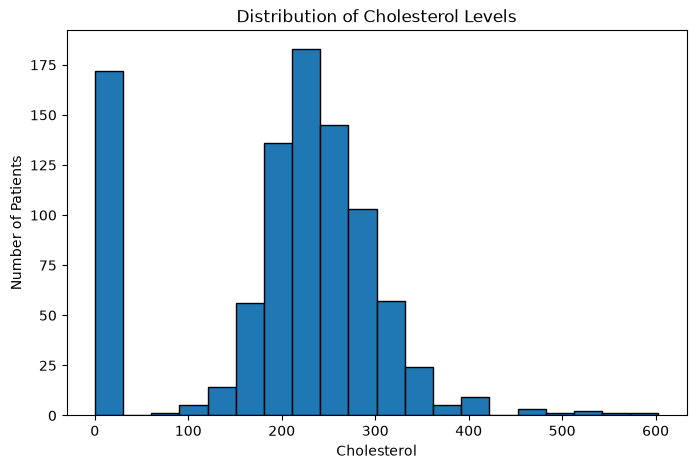

In [20]:
# Plot a histogram to visualize the distribution of cholesterol levels
plt.figure(figsize=(8, 5))

df["Cholesterol"].plot(kind="hist", bins=20, edgecolor="black")

# Add descriptive labels to the plot
plt.title("Distribution of Cholesterol Levels")
plt.xlabel("Cholesterol")
plt.ylabel("Number of Patients")

# Display the histogram
plt.show()

**Investigating Zero Values in `Cholesterol`**

The histogram shows a large concentration of observations at a cholesterol
value of zero, while most non-zero values are distributed at much higher
levels.

Since zero may represent an invalid or unrecorded cholesterol measurement, I
will check how many observations contain `Cholesterol = 0`.

In [21]:
# Count observations where Cholesterol is equal to zero
cholesterol_zero_count = (df["Cholesterol"] == 0).sum()

# Display the number of zero values
cholesterol_zero_count

np.int64(172)

**Observation**

The histogram revealed a large concentration of observations with a
cholesterol value of zero.

A direct check confirmed that 172 out of 918 observations have
`Cholesterol = 0`.

Because zero is not a plausible cholesterol measurement, these values are
treated as a data-quality issue that requires further handling. The values
will not be modified during EDA; the appropriate treatment will be addressed
later during data preparation and incorporated into the machine-learning
pipeline.

**Investigating Potential Outliers in `Cholesterol`**

The histogram showed that most non-zero cholesterol values are concentrated
within a lower range, while some observations extend to much higher values.

A boxplot will be used to examine the spread of the cholesterol values and
identify potential outliers based on the distribution.

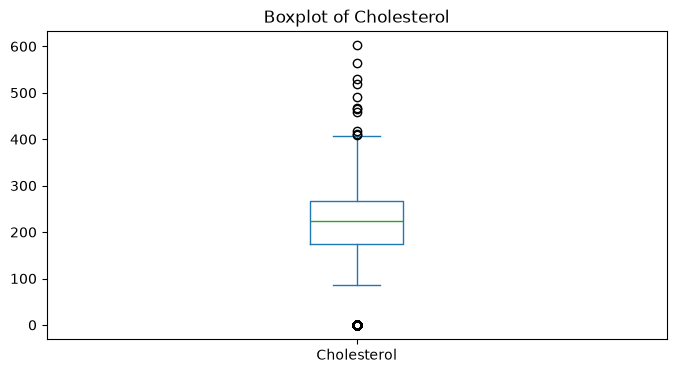

In [22]:
# Create a boxplot to visualize the distribution and potential outliers
plt.figure(figsize=(8, 4))

df["Cholesterol"].plot(kind="box")

# Add a descriptive title
plt.title("Boxplot of Cholesterol")

# Display the plot
plt.show()

**Calculating the IQR for `Cholesterol`**

The boxplot suggests the presence of potential outliers in the cholesterol
feature.

I will use the Interquartile Range (IQR) method to calculate the lower and
upper boundaries for identifying potential statistical outliers.

In [23]:
# Calculate the first and third quartiles
Q1 = df["Cholesterol"].quantile(0.25)
Q3 = df["Cholesterol"].quantile(0.75)

# Calculate the Interquartile Range
IQR = Q3 - Q1

# Calculate the lower and upper outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Display the calculated values
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 173.25
Q3: 267.0
IQR: 93.75
Lower Bound: 32.625
Upper Bound: 407.625


**Identifying Potential Statistical Outliers**

The IQR method produced a lower boundary of 32.625 and an upper boundary of
407.625.

I will now count how many observations fall outside these boundaries to
quantify the potential statistical outliers identified by the boxplot.

In [24]:
# Identify cholesterol values below the lower IQR boundary
lower_outliers = df[df["Cholesterol"] < lower_bound]

# Identify cholesterol values above the upper IQR boundary
upper_outliers = df[df["Cholesterol"] > upper_bound]

# Count the potential outliers in each direction
print("Lower outliers:", len(lower_outliers))
print("Upper outliers:", len(upper_outliers))

# Count all potential statistical outliers
total_outliers = len(lower_outliers) + len(upper_outliers)

print("Total potential outliers:", total_outliers)

Lower outliers: 172
Upper outliers: 11
Total potential outliers: 183


**Cholesterol Outlier Analysis — Findings**

The IQR analysis identified 183 potential statistical outliers in the
`Cholesterol` feature.

- 172 observations fall below the lower IQR boundary of 32.625.
- 11 observations fall above the upper IQR boundary of 407.625.

The 172 lower outliers correspond exactly to the 172 observations where
`Cholesterol = 0`. Since zero is not a plausible cholesterol measurement,
these values are considered a data-quality issue rather than ordinary
statistical outliers.

The 11 upper outliers represent unusually high cholesterol measurements.
However, they cannot automatically be considered invalid values simply
because they are statistical outliers. They will be retained for further
investigation and handled appropriately during the data-preparation stage.

---

**Understanding the `MaxHR` Feature**

The `MaxHR` feature represents the maximum heart rate recorded for each
observation during the exercise test.

A histogram will be used to examine the distribution of maximum heart rate
values across the dataset.

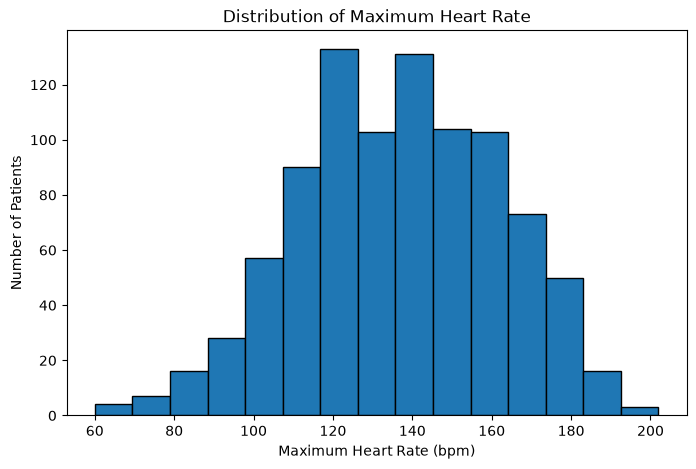

In [25]:
# Plot a histogram to visualize the distribution of maximum heart rate
plt.figure(figsize=(8, 5))

df["MaxHR"].plot(kind="hist", bins=15, edgecolor="black")

# Add descriptive labels to the plot
plt.title("Distribution of Maximum Heart Rate")
plt.xlabel("Maximum Heart Rate (bpm)")
plt.ylabel("Number of Patients")

# Display the histogram
plt.show()

**Observation**

The `MaxHR` distribution is concentrated mainly between approximately
110 and 170 bpm, with higher frequencies appearing around the 120–150 bpm
range.

The distribution appears roughly bell-shaped, although it is not perfectly
symmetric. The observed values range from approximately 60 to 200 bpm, with
fewer observations near the lower and upper extremes.

The histogram does not show any clearly isolated extreme values. However,
a histogram alone is not sufficient to determine statistical outliers, so
formal outlier analysis would require additional methods such as a boxplot
and the IQR rule.

---

**Understanding the `Oldpeak` Feature**

The `Oldpeak` feature represents the ST-segment change associated with
exercise compared with the resting baseline.

A histogram will be used to examine how `Oldpeak` values are distributed
across the dataset and identify any unusual patterns.

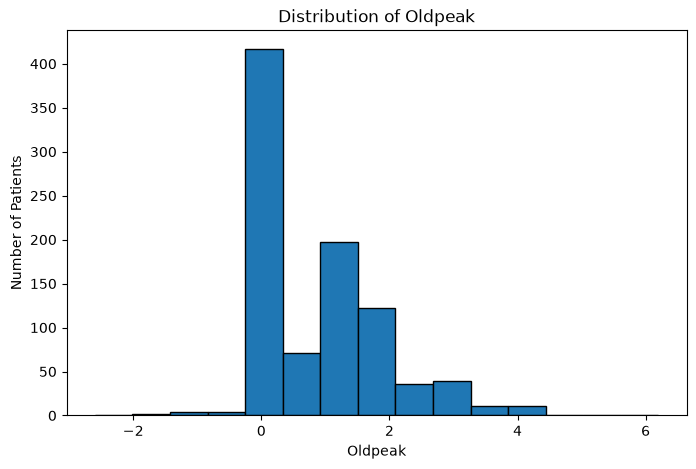

In [26]:
# Plot a histogram to visualize the distribution of Oldpeak
plt.figure(figsize=(8, 5))

df["Oldpeak"].plot(kind="hist", bins=15, edgecolor="black")

# Add descriptive labels to the plot
plt.title("Distribution of Oldpeak")
plt.xlabel("Oldpeak")
plt.ylabel("Number of Patients")

# Display the histogram
plt.show()

**Observation**

The `Oldpeak` distribution is strongly concentrated around zero. The frequency
of observations decreases as the `Oldpeak` value increases, producing a
right-skewed distribution.

Most of the observed values are concentrated between approximately 0 and 3,
while a smaller number of observations extend to higher values, reaching
approximately 6.2.

The dataset also contains some negative `Oldpeak` values, with the minimum
value being -2.6. These values are not automatically considered invalid and
will be interpreted in the context of the feature definition and subsequent
analysis.

Overall, the distribution is clearly not symmetric or normally distributed.

---

**Understanding the `FastingBS` Feature**

The `FastingBS` feature represents fasting blood sugar status.

It is encoded as a binary variable:
- `0` represents fasting blood sugar at or below 120 mg/dl.
- `1` represents fasting blood sugar above 120 mg/dl.

Since this feature contains two discrete categories, a bar chart will be used
to examine the frequency of each category.

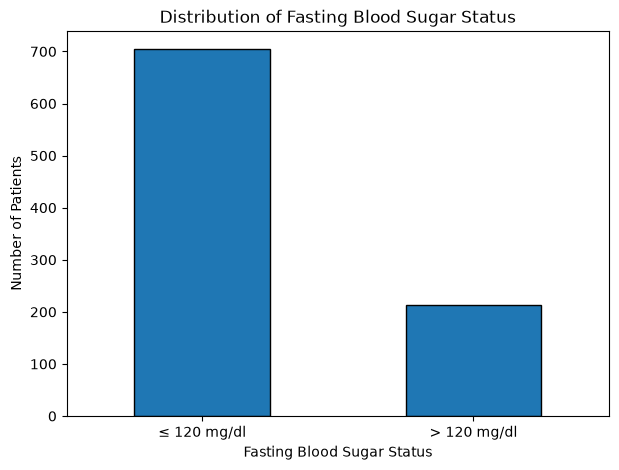

In [27]:
# Count the observations in each FastingBS category
fasting_bs_counts = df["FastingBS"].value_counts().sort_index()

# Create a bar chart to visualize the category frequencies
plt.figure(figsize=(7, 5))

fasting_bs_counts.plot(kind="bar", edgecolor="black")

# Add descriptive labels to the plot
plt.title("Distribution of Fasting Blood Sugar Status")
plt.xlabel("Fasting Blood Sugar Status")
plt.ylabel("Number of Patients")

# Make the x-axis labels easier to understand
plt.xticks(
    ticks=[0, 1],
    labels=["≤ 120 mg/dl", "> 120 mg/dl"],
    rotation=0
)

# Display the chart
plt.show()

**Checking the Exact Category Frequencies**

The bar chart shows that the two `FastingBS` categories are not equally represented, with the `0` category appearing much more frequently. I will retrieve the exact counts.

In [28]:
# Count the exact number of observations in each FastingBS category
fasting_bs_counts

FastingBS
0    704
1    214
Name: count, dtype: int64

In [29]:
# Calculate the percentage of observations in each FastingBS category
fasting_bs_percentages = df["FastingBS"].value_counts(normalize=True).sort_index() * 100

# Display the percentages
fasting_bs_percentages

FastingBS
0    76.688453
1    23.311547
Name: proportion, dtype: float64

**Observation**

The distribution of `FastingBS` is clearly uneven between its two categories.

There are 704 observations with `FastingBS = 0`, representing approximately
76.7% of the dataset, while 214 observations have `FastingBS = 1`,
representing approximately 23.3%.

This shows that the `FastingBS` feature is dominated by the `0` category.
This imbalance describes the distribution of this feature and should not be
confused with the class balance of the target variable `HeartDisease`.

---

## 5. Target Variable Analysis

Before investigating feature-target relationships, I will examine the target variable `HeartDisease` to understand the class balance. An imbalanced target affects which evaluation metrics are most informative.

In [30]:
# Count the number of observations in each target class
heart_disease_counts = df["HeartDisease"].value_counts().sort_index()

# Display the class frequencies
heart_disease_counts

HeartDisease
0    410
1    508
Name: count, dtype: int64

**Target Class Proportions**

The target counts show that the two classes are not exactly equal in size.

I will calculate the percentage of observations belonging to each
`HeartDisease` class to assess the class balance more clearly.

In [31]:
# Calculate the percentage of observations in each target class
heart_disease_percentages = (
    df["HeartDisease"].value_counts(normalize=True).sort_index() * 100
)

# Display the class percentages
heart_disease_percentages

HeartDisease
0    44.662309
1    55.337691
Name: proportion, dtype: float64

**Visualizing the Target Distribution**

The target classes are relatively close in size, although the `HeartDisease = 1`
class is slightly more frequent.

A bar chart will be used to visualize the class distribution and make the
difference between the two classes easier to interpret.

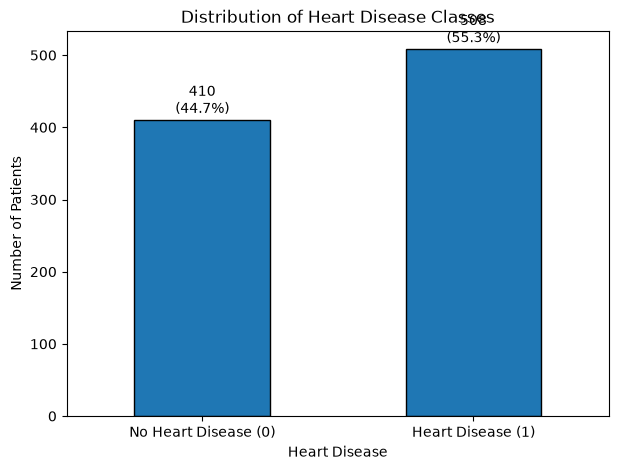

In [32]:
# Create a bar chart for the target class distribution
plt.figure(figsize=(7, 5))

ax = heart_disease_counts.plot(
    kind="bar",
    edgecolor="black"
)

# Add descriptive labels to the chart
plt.title("Distribution of Heart Disease Classes")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")

# Make the class labels easier to understand
plt.xticks(
    ticks=[0, 1],
    labels=["No Heart Disease (0)", "Heart Disease (1)"],
    rotation=0
)

# Add the exact count above each bar
for i, count in enumerate(heart_disease_counts):
    ax.text(
        i,
        count + 10,
        f"{count}\n({heart_disease_percentages.iloc[i]:.1f}%)",
        ha="center"
    )

# Display the chart
plt.show()

**Observation**

The target variable contains 410 observations in class 0 (44.7%) and
508 observations in class 1 (55.3%).

Although class 1 is slightly more frequent, the two classes are relatively
close in size. Therefore, the target does not show severe class imbalance,
which is favorable for the classification task.

The target distribution will still be considered when evaluating the
classification models, particularly when interpreting precision, recall,
F1-score, and the confusion matrix.

---

## 6. Feature vs Target Analysis

With individual feature distributions understood, I will now investigate how each feature relates to the `HeartDisease` target. Features that separate the two classes well are the most informative for modeling.

### Age Distribution by Heart Disease Class

The `Age` feature will be compared across the two `HeartDisease` classes.

A grouped boxplot is used to compare the central tendency, spread, and
potential extreme values of age between the two target classes.

C:\Users\user\AppData\Local\Temp\ipykernel_23024\1859566397.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


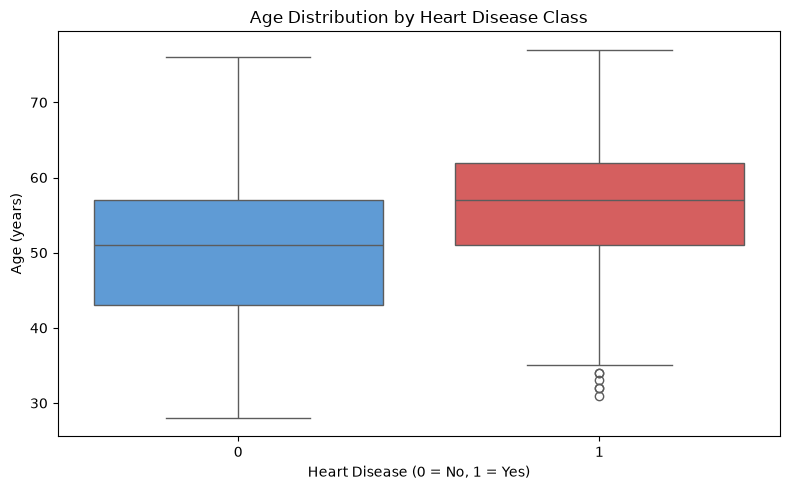

In [33]:
# Compare the distribution of Age across the two HeartDisease classes
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="HeartDisease",
    y="Age",
    palette=["#4C9BE8", "#E84C4C"]
)

plt.title("Age Distribution by Heart Disease Class")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Age (years)")
plt.tight_layout()
plt.show()

**Observation**

The boxplot shows a noticeable difference in the age distributions between
the two target classes.

The median age is approximately 51 years for observations with
`HeartDisease = 0`, compared with approximately 57 years for observations
with `HeartDisease = 1`.

The distribution for the heart disease class is therefore shifted toward
higher ages. A few potential outliers with relatively young ages are also
visible in the `HeartDisease = 1` group.

This suggests an association between age and the target variable in this
dataset. However, this observation does not imply that age causes heart
disease.

---

### Maximum Heart Rate by Heart Disease Class

The `MaxHR` feature will be compared across the two `HeartDisease` classes.

A grouped boxplot is used to examine whether the distribution of maximum
heart rate differs between observations with and without heart disease.

C:\Users\user\AppData\Local\Temp\ipykernel_23024\3778753147.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


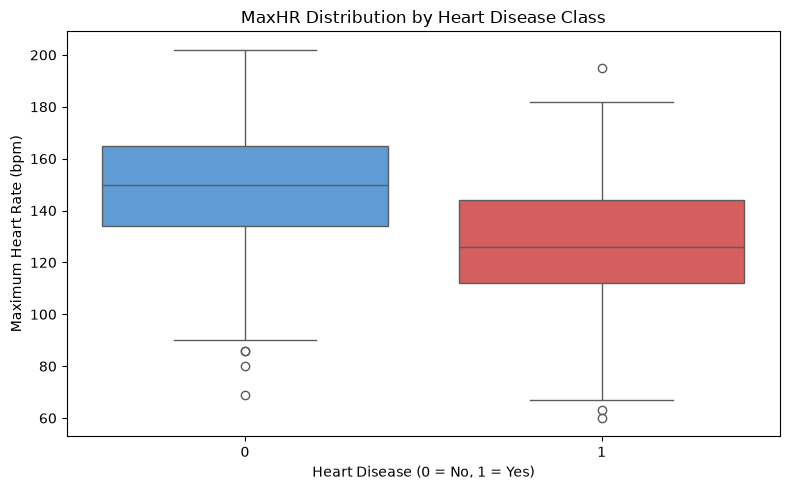

In [34]:
# Compare the distribution of MaxHR across the two HeartDisease classes
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="HeartDisease",
    y="MaxHR",
    palette=["#4C9BE8", "#E84C4C"]
)

plt.title("MaxHR Distribution by Heart Disease Class")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Maximum Heart Rate (bpm)")
plt.tight_layout()
plt.show()

**Observation**

The boxplot shows a clear difference in the `MaxHR` distributions between
the two target classes.

The median maximum heart rate is approximately 150 bpm for observations with
`HeartDisease = 0`, compared with approximately 125 bpm for observations with
`HeartDisease = 1`.

The `HeartDisease = 1` group is therefore shifted toward lower maximum heart
rate values. Several potential outliers are also visible in both groups.

This suggests an association between maximum heart rate and the target
variable in this dataset. However, this observation does not imply that a
lower maximum heart rate causes heart disease.

---

### Oldpeak Distribution by Heart Disease Class

The `Oldpeak` feature showed a strongly right-skewed distribution when
examined independently.

A grouped boxplot will now be used to compare the `Oldpeak` distributions
between the two `HeartDisease` classes and investigate whether their central
tendency and spread differ.

C:\Users\user\AppData\Local\Temp\ipykernel_23024\1028401131.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


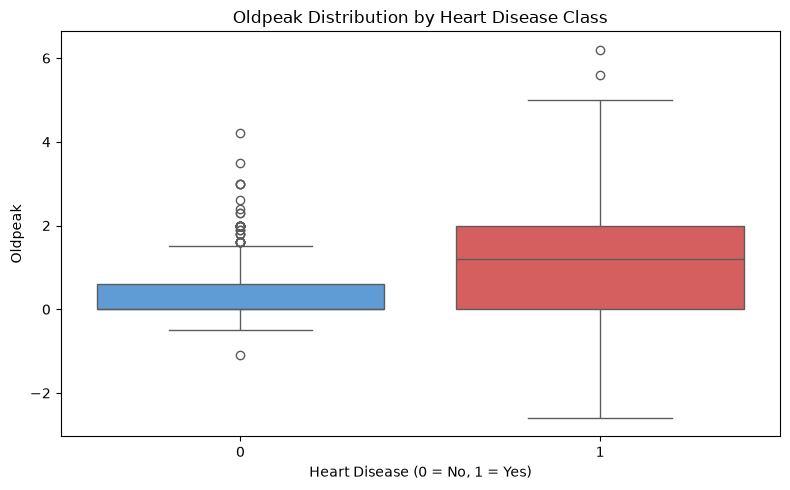

In [35]:
# Compare the distribution of Oldpeak across the two HeartDisease classes
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="HeartDisease",
    y="Oldpeak",
    palette=["#4C9BE8", "#E84C4C"]
)

plt.title("Oldpeak Distribution by Heart Disease Class")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Oldpeak")
plt.tight_layout()
plt.show()

**Observation**

The boxplot shows a clear difference in the `Oldpeak` distributions between
the two target classes.

The median `Oldpeak` is approximately 0.2 for observations with
`HeartDisease = 0`, compared with approximately 1.2 for observations with
`HeartDisease = 1`.

The heart disease group also shows a wider spread of `Oldpeak` values,
while the no-heart-disease group is strongly concentrated near zero.

Several potential outliers are visible in both groups, particularly at higher
values. These observations are retained at this stage because statistical
outliers are not automatically invalid measurements.

Overall, `Oldpeak` shows a noticeable association with the target variable in
this dataset.

---

### Resting Blood Pressure by Heart Disease Class

The `RestingBP` feature will be compared across the two `HeartDisease`
classes.

A grouped boxplot will be used to examine differences in the central
tendency and spread of resting blood pressure between the two groups.

C:\Users\user\AppData\Local\Temp\ipykernel_23024\1845355594.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


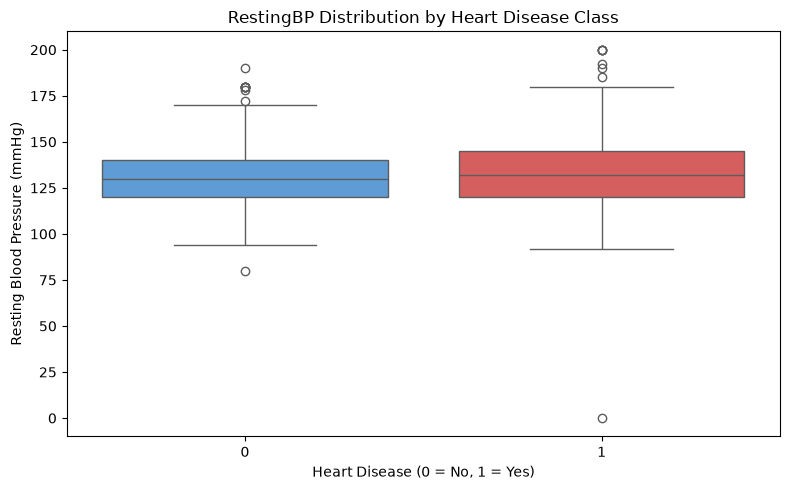

In [36]:
# Compare the distribution of RestingBP across the two HeartDisease classes
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="HeartDisease",
    y="RestingBP",
    palette=["#4C9BE8", "#E84C4C"]
)

plt.title("RestingBP Distribution by Heart Disease Class")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Resting Blood Pressure (mmHg)")
plt.tight_layout()
plt.show()

**Observation**

The `RestingBP` distributions are relatively similar between the two target
classes.

The median resting blood pressure is approximately 130 for
`HeartDisease = 0` and approximately 132–133 for `HeartDisease = 1`,
indicating only a small difference in central tendency.

Both groups contain several potential high-value outliers. A particularly
notable observation is a `RestingBP` value of 0 in the heart disease group,
which is not a plausible resting blood pressure measurement and represents a
data-quality issue that will be addressed during data preparation.

Overall, the boxplot does not show a strong separation between the two target
classes based on resting blood pressure alone.

---

### Cholesterol Distribution by Heart Disease Class

The `Cholesterol` feature previously showed a substantial number of zero
values and several potential statistical outliers.

A grouped boxplot will now be used to compare the cholesterol distributions
between the two target classes and examine whether their central tendency or
spread differs.

C:\Users\user\AppData\Local\Temp\ipykernel_23024\1095740885.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


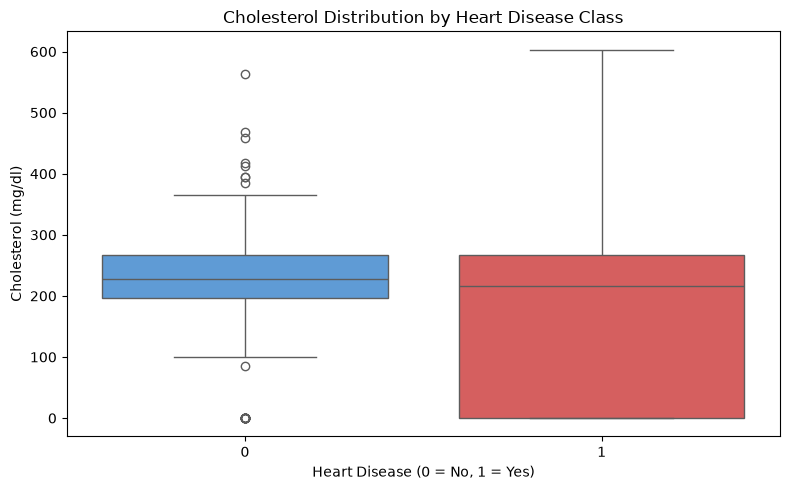

In [37]:
# Compare the distribution of Cholesterol across the two HeartDisease classes
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="HeartDisease",
    y="Cholesterol",
    palette=["#4C9BE8", "#E84C4C"]
)

plt.title("Cholesterol Distribution by Heart Disease Class")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Cholesterol (mg/dl)")
plt.tight_layout()
plt.show()

**Observation**

The cholesterol distributions show some differences between the two target
classes.

The median cholesterol level appears to be slightly higher in the
`HeartDisease = 0` group, while the `HeartDisease = 1` group shows a wider
spread. Both groups contain several potential high-value outliers.

A particularly important data-quality issue is the presence of
`Cholesterol = 0` observations in both target classes. These values were
previously identified as statistically unusual and are not plausible
cholesterol measurements.

The zero values will therefore be treated as suspicious values that require
further handling during the data-preparation stage. They will not be removed
during EDA.

Overall, the boxplot suggests differences in the cholesterol distributions
between the two target classes, but it does not establish a causal
relationship between cholesterol and heart disease.

---

### Sex Distribution by Heart Disease Class

The `Sex` feature is categorical, with two categories: `M` and `F`.

A grouped bar chart will be used to compare the frequency of each sex across
the two `HeartDisease` classes.

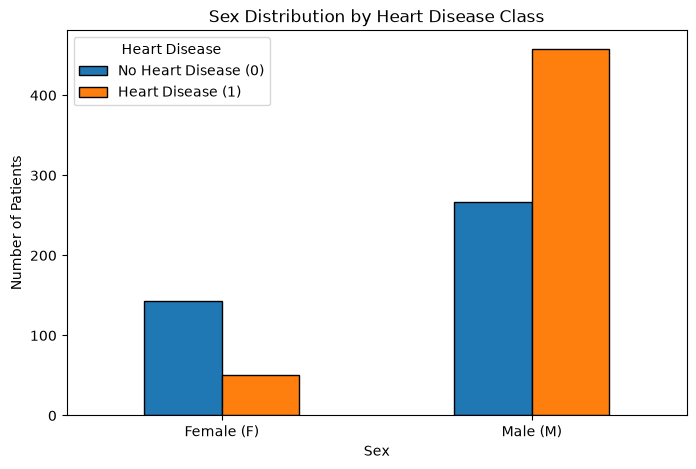

In [38]:
# Create a cross-tabulation of Sex and HeartDisease
sex_heart_disease = pd.crosstab(
    df["Sex"],
    df["HeartDisease"]
)

# Create a grouped bar chart
ax = sex_heart_disease.plot(
    kind="bar",
    figsize=(8, 5),
    edgecolor="black"
)

# Add descriptive labels
plt.title("Sex Distribution by Heart Disease Class")
plt.xlabel("Sex")
plt.ylabel("Number of Patients")

# Make the x-axis labels clearer
plt.xticks(
    ticks=[0, 1],
    labels=["Female (F)", "Male (M)"],
    rotation=0
)

# Add a legend with meaningful class names
plt.legend(
    title="Heart Disease",
    labels=["No Heart Disease (0)", "Heart Disease (1)"]
)

# Display the chart
plt.show()

**Proportion of Heart Disease Within Each Sex**

The previous chart showed the raw number of observations in each category.
However, the number of male and female observations is very different.

To make a fairer comparison, the target distribution will be converted to
percentages within each sex.

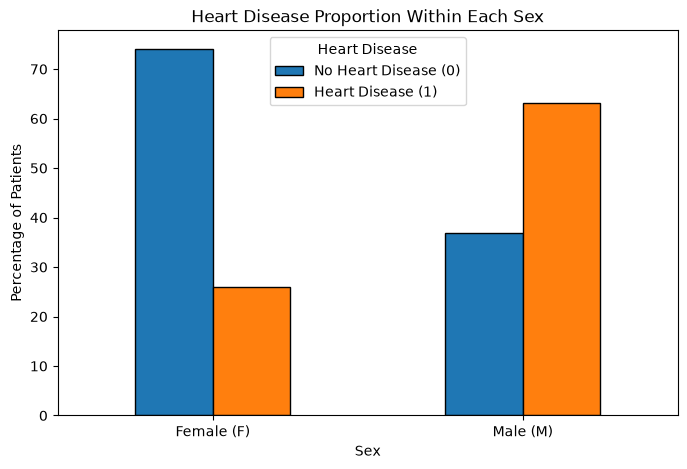

In [39]:
# Calculate the proportion of each HeartDisease class within each sex
sex_heart_disease_percentage = pd.crosstab(
    df["Sex"],
    df["HeartDisease"],
    normalize="index"
) * 100

# Create a grouped bar chart using percentages
ax = sex_heart_disease_percentage.plot(
    kind="bar",
    figsize=(8, 5),
    edgecolor="black"
)

# Add descriptive labels
plt.title("Heart Disease Proportion Within Each Sex")
plt.xlabel("Sex")
plt.ylabel("Percentage of Patients")

# Make the x-axis labels clearer
plt.xticks(
    ticks=[0, 1],
    labels=["Female (F)", "Male (M)"],
    rotation=0
)

# Add a meaningful legend
plt.legend(
    title="Heart Disease",
    labels=["No Heart Disease (0)", "Heart Disease (1)"]
)

# Display the chart
plt.show()

**Observation**

The normalized bar chart shows a substantial difference in the distribution
of the target variable between the two sex categories.

Among females, approximately 74% of observations belong to
`HeartDisease = 0`, while approximately 26% belong to `HeartDisease = 1`.

Among males, approximately 37% of observations belong to
`HeartDisease = 0`, while approximately 63% belong to `HeartDisease = 1`.

Because the percentages are calculated within each sex, this visualization
provides a more appropriate comparison than raw counts given the different
numbers of male and female observations.

Overall, the proportion of `HeartDisease = 1` observations is substantially
higher among males than females in this dataset. This represents an observed
association and does not establish a causal or clinical relationship.

---

### Heart Disease Proportion by Chest Pain Type

`ChestPainType` is a categorical feature with four categories:
`ASY`, `NAP`, `ATA`, and `TA`.

The proportion of each heart disease class within every chest pain category
will be compared to investigate whether the target distribution differs
across chest pain types.

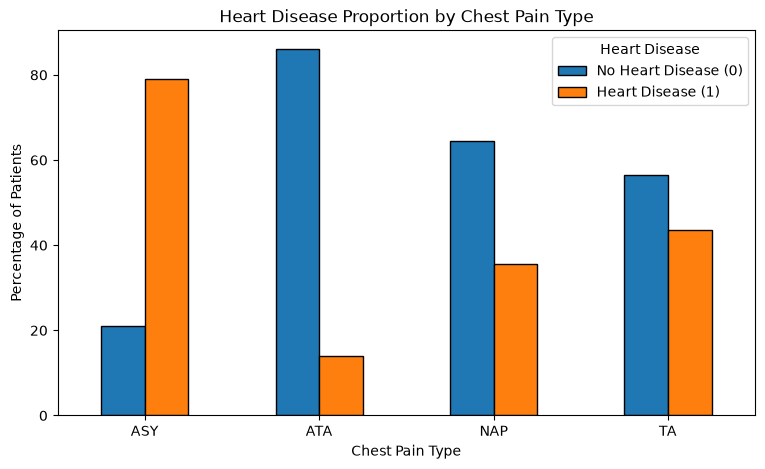

In [40]:
# Calculate the proportion of each HeartDisease class within each chest pain type
chest_pain_proportion = pd.crosstab(
    df["ChestPainType"],
    df["HeartDisease"],
    normalize="index"
) * 100

# Create a grouped bar chart using percentages
ax = chest_pain_proportion.plot(
    kind="bar",
    figsize=(9, 5),
    edgecolor="black"
)

# Add descriptive labels
plt.title("Heart Disease Proportion by Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("Percentage of Patients")

# Keep the category labels readable
plt.xticks(rotation=0)

# Add a meaningful legend
plt.legend(
    title="Heart Disease",
    labels=["No Heart Disease (0)", "Heart Disease (1)"]
)

# Display the chart
plt.show()

**Observation**

The target distribution varies substantially across the different chest pain
categories.

The `ASY` category has the highest proportion of `HeartDisease = 1`
observations, at approximately 79%. In contrast, the `ATA` category has the
lowest proportion of `HeartDisease = 1`, at approximately 14%.

The `NAP` and `TA` categories show more mixed target distributions.

Overall, `ChestPainType` shows a strong association with the target variable
in this dataset. However, this exploratory analysis does not establish a
causal or clinical relationship, nor does it by itself determine the feature's
importance in the final machine-learning models.

---

### Heart Disease Proportion by Exercise-Induced Angina

`ExerciseAngina` indicates whether exercise-induced angina is recorded for an
observation.

The target proportions within the `Y` and `N` categories will be compared to
investigate whether the distribution of `HeartDisease` differs between the
two groups.

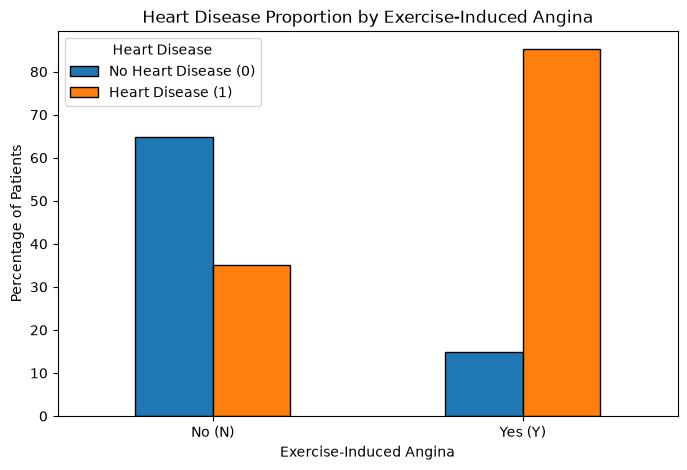

In [41]:
# Calculate the proportion of each HeartDisease class within each ExerciseAngina category
exercise_angina_proportion = pd.crosstab(
    df["ExerciseAngina"],
    df["HeartDisease"],
    normalize="index"
) * 100

# Create a grouped bar chart using percentages
ax = exercise_angina_proportion.plot(
    kind="bar",
    figsize=(8, 5),
    edgecolor="black"
)

# Add descriptive labels
plt.title("Heart Disease Proportion by Exercise-Induced Angina")
plt.xlabel("Exercise-Induced Angina")
plt.ylabel("Percentage of Patients")

# Make the category labels easier to understand
plt.xticks(
    ticks=[0, 1],
    labels=["No (N)", "Yes (Y)"],
    rotation=0
)

# Add a meaningful legend
plt.legend(
    title="Heart Disease",
    labels=["No Heart Disease (0)", "Heart Disease (1)"]
)

# Display the chart
plt.show()

**Observation**

The target distribution differs substantially between the two
`ExerciseAngina` categories.

Among observations with `ExerciseAngina = N`, approximately 65% belong to
`HeartDisease = 0` and 35% belong to `HeartDisease = 1`.

In contrast, among observations with `ExerciseAngina = Y`, approximately 15%
belong to `HeartDisease = 0` while approximately 85% belong to
`HeartDisease = 1`.

This indicates a strong association between `ExerciseAngina` and the target
variable in this dataset. However, the observed relationship does not imply
causation and does not by itself determine the feature's importance in the
final machine-learning models.

---

### Heart Disease Proportion by ST Segment Slope

`ST_Slope` is a categorical feature with three categories:
`Up`, `Flat`, and `Down`.

The proportion of each target class within every `ST_Slope` category will be
examined to determine whether the target distribution differs across the
categories.

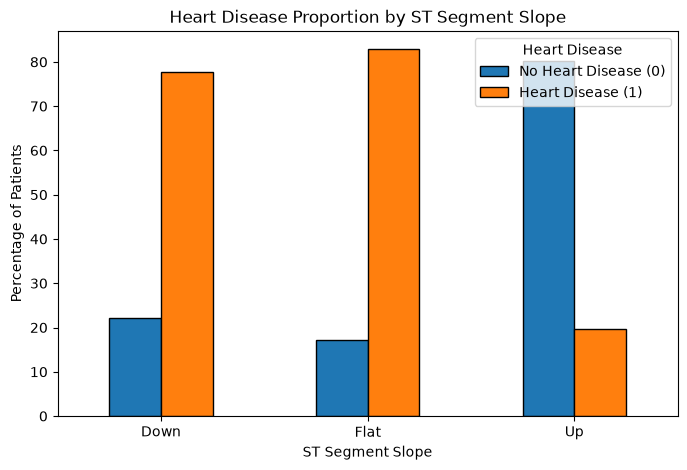

In [42]:
# Calculate the proportion of each HeartDisease class within each ST_Slope category
st_slope_proportion = pd.crosstab(
    df["ST_Slope"],
    df["HeartDisease"],
    normalize="index"
) * 100

# Create a grouped bar chart using percentages
ax = st_slope_proportion.plot(
    kind="bar",
    figsize=(8, 5),
    edgecolor="black"
)

# Add descriptive labels
plt.title("Heart Disease Proportion by ST Segment Slope")
plt.xlabel("ST Segment Slope")
plt.ylabel("Percentage of Patients")

# Keep the category labels readable
plt.xticks(rotation=0)

# Add a meaningful legend
plt.legend(
    title="Heart Disease",
    labels=["No Heart Disease (0)", "Heart Disease (1)"]
)

# Display the chart
plt.show()

**Observation**

The target distribution varies substantially across the `ST_Slope`
categories.

The `Up` category contains approximately 20% `HeartDisease = 1`
observations, while the `Flat` category contains approximately 83%.
The `Down` category also shows a high proportion of `HeartDisease = 1`,
at approximately 78%.

The `Down` category contains considerably fewer observations than the other
two categories, so its proportion should be interpreted with additional
caution.

Overall, `ST_Slope` shows a strong association with the target variable in
this dataset. However, this exploratory pattern does not establish causation
or determine the feature's predictive importance by itself.

---

### Heart Disease Proportion by Resting ECG

`RestingECG` is a categorical feature with three categories:
`Normal`, `ST`, and `LVH`.

The proportion of each target class within every `RestingECG` category will
be examined to determine whether the target distribution differs across the
categories.

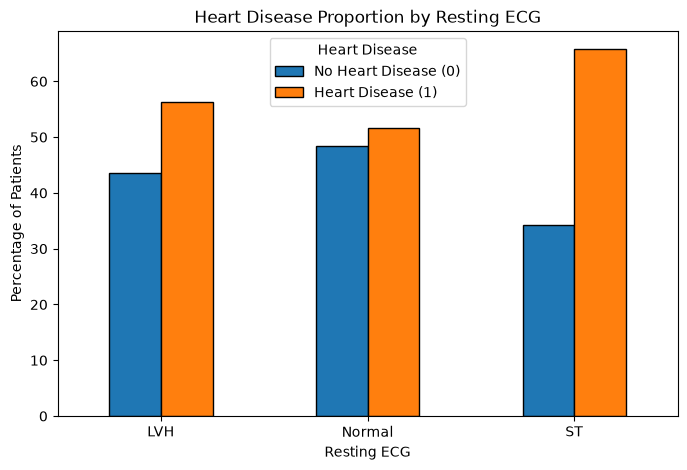

In [43]:
# Calculate the proportion of each HeartDisease class within each RestingECG category
resting_ecg_proportion = pd.crosstab(
    df["RestingECG"],
    df["HeartDisease"],
    normalize="index"
) * 100

# Create a grouped bar chart using percentages
ax = resting_ecg_proportion.plot(
    kind="bar",
    figsize=(8, 5),
    edgecolor="black"
)

# Add descriptive labels
plt.title("Heart Disease Proportion by Resting ECG")
plt.xlabel("Resting ECG")
plt.ylabel("Percentage of Patients")

# Keep the category labels readable
plt.xticks(rotation=0)

# Add a meaningful legend
plt.legend(
    title="Heart Disease",
    labels=["No Heart Disease (0)", "Heart Disease (1)"]
)

# Display the chart
plt.show()

**Observation**

The target distribution varies across the `RestingECG` categories, although
the strength of the difference is smaller than that observed for some other
categorical features.

The `Normal` category has a nearly balanced target distribution, with
approximately 48.5% of observations belonging to `HeartDisease = 0` and
51.5% belonging to `HeartDisease = 1`.

The `ST` category shows a larger difference, with approximately 66% of
observations belonging to `HeartDisease = 1`. The `LVH` category shows a more
moderate difference, with approximately 56.5% belonging to
`HeartDisease = 1`.

Overall, `RestingECG` shows some association with the target variable, but the
relationship appears less pronounced than the patterns observed for features
such as `ChestPainType`, `ExerciseAngina`, and `ST_Slope`.

---

## EDA Summary — Key Findings

The table below summarizes the most important patterns identified during the exploratory analysis. These findings guided the feature engineering and modeling decisions in Section 9.

| Feature | Relationship with Heart Disease |
|---|---|
| `ST_Slope` | **Strong** — `Flat` slope: ~83% disease rate; `Up` slope: ~20% disease rate |
| `ChestPainType` | **Strong** — `ASY` patients: ~79% disease rate; `ATA`: ~25% |
| `ExerciseAngina` | **Strong** — with angina: ~85% disease rate vs. ~35% without |
| `MaxHR` | **Clear** — median 150 bpm (no disease) vs. 125 bpm (disease) |
| `Oldpeak` | **Clear** — median 0.2 (no disease) vs. 1.2 (disease) |
| `Sex` | **Moderate** — 63% disease rate in males vs. 26% in females |
| `Age` | **Moderate** — median 51 (no disease) vs. 57 (disease) |
| `RestingBP` | **Weak** — distributions are very similar between classes |
| `Cholesterol` | **Noisy** — 172 zero values reduce reliability before imputation |

## 7. Correlation Analysis

Correlation analysis examines the strength and direction of linear relationships between numerical features. A correlation coefficient ranges from −1 to +1:

- Values close to **+1** indicate a strong positive linear relationship.
- Values close to **−1** indicate a strong negative linear relationship.
- Values close to **0** indicate little to no linear relationship.

The target variable `HeartDisease` is included so that feature-target correlations can be read directly from the matrix.

In [354]:
# Select the numerical columns from the cleaned dataset
numeric_columns = df.select_dtypes(include="number").columns

# Calculate the Pearson correlation matrix
correlation_matrix = df[numeric_columns].corr()

# Display the correlation matrix
correlation_matrix

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
Age,1.000000,0.254399,-0.095282,0.198039,-0.382045,0.258612,0.282039
RestingBP,0.254399,1.000000,0.100893,0.070193,-0.112135,0.164803,0.107589
Cholesterol,-0.095282,0.100893,1.000000,-0.260974,0.235792,0.050148,-0.232741
FastingBS,0.198039,0.070193,-0.260974,1.000000,-0.131438,0.052698,0.267291
MaxHR,-0.382045,-0.112135,0.235792,-0.131438,1.000000,-0.160691,-0.400421
Oldpeak,0.258612,0.164803,0.050148,0.052698,-0.160691,1.000000,0.403951
HeartDisease,0.282039,0.107589,-0.232741,0.267291,-0.400421,0.403951,1.000000


**Correlation Heatmap**

The correlation matrix provides numerical measurements of the linear
relationships between numerical features.

A heatmap will now be used to visualize the same correlations, making stronger
positive and negative relationships easier to identify.

The target variable `HeartDisease` is included to examine its linear
association with the numerical features.

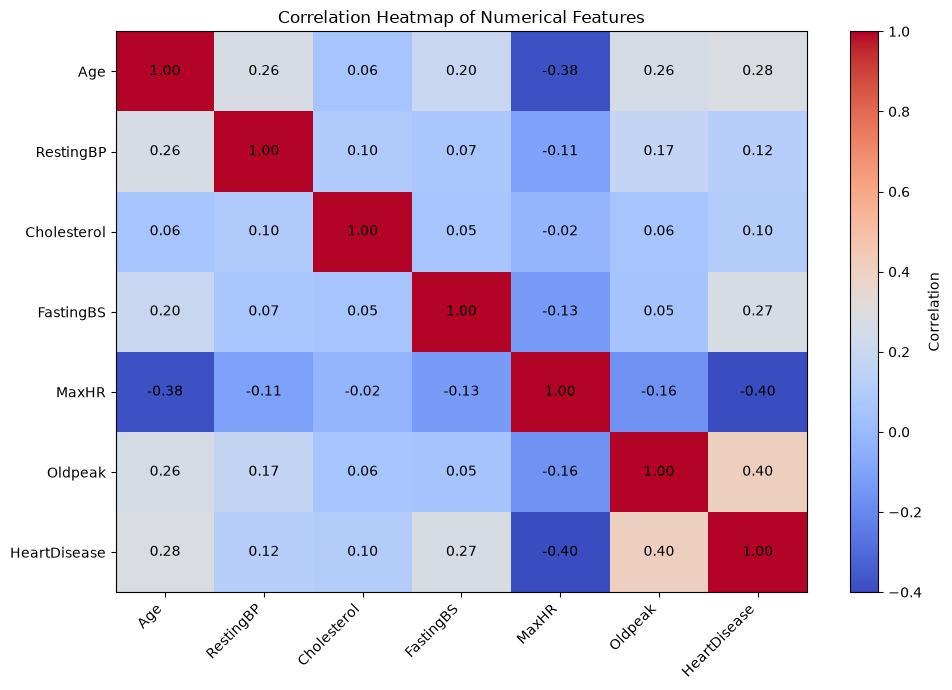

In [ ]:
# Create the correlation heatmap using seaborn
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True
)

plt.title("Pearson Correlation Matrix — Numerical Features", pad=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation**

The correlation analysis shows that `Oldpeak` and `MaxHR` have the strongest
linear associations with the `HeartDisease` target.

`Oldpeak` has a positive correlation of approximately 0.40, while `MaxHR` has
a negative correlation of approximately -0.40. This means that higher
`Oldpeak` values and lower `MaxHR` values are associated with
`HeartDisease = 1` in this dataset.

`Age` and `FastingBS` show weaker positive correlations with the target, while
`RestingBP` and `Cholesterol` show relatively weak linear associations.

Among the numerical features, the strongest feature-to-feature relationship
is between `Age` and `MaxHR` at approximately -0.38. The remaining correlations
are relatively weak, suggesting that there is no strong linear redundancy
among the numerical features.

These correlations describe associations in the dataset and do not imply
causation or determine model feature importance.

---

### Investigating the Age–Maximum Heart Rate Relationship

The correlation matrix identified a negative correlation of approximately
-0.38 between `Age` and `MaxHR`.

A scatter plot will be used to visually examine this relationship and
determine whether older patients generally tend to have lower maximum heart
rates.

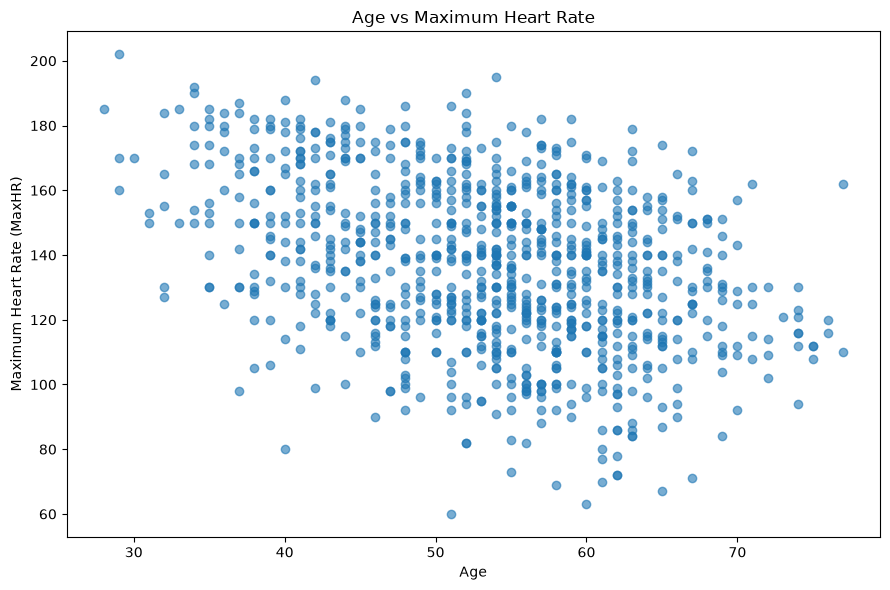

In [355]:
# Create a scatter plot to examine the relationship between Age and MaxHR
plt.figure(figsize=(9, 6))

# Plot each observation as a point
plt.scatter(
    df["Age"],
    df["MaxHR"],
    alpha=0.6
)

# Add labels and title
plt.xlabel("Age")
plt.ylabel("Maximum Heart Rate (MaxHR)")
plt.title("Age vs Maximum Heart Rate")

# Display the plot
plt.tight_layout()
plt.show()

**Observation**

The scatter plot visually supports the negative correlation identified in the
correlation matrix.

As `Age` increases, `MaxHR` generally tends to decrease. However, the points
show substantial dispersion rather than forming a narrow linear pattern,
which is consistent with the moderate correlation of approximately -0.38.

Several observations appear far from the main concentration of points,
particularly at very high or very low `MaxHR` values. These observations will
be retained at this stage because a visually unusual value is not necessarily
an invalid observation.

Overall, the scatter plot provides visual evidence consistent with the
negative linear association between `Age` and `MaxHR`.

---

### Investigating the Oldpeak–Maximum Heart Rate Relationship

The correlation matrix showed a weak negative correlation of approximately
-0.16 between `Oldpeak` and `MaxHR`.

A scatter plot will be used to visually investigate whether this weak
relationship can be observed in the distribution of the data.

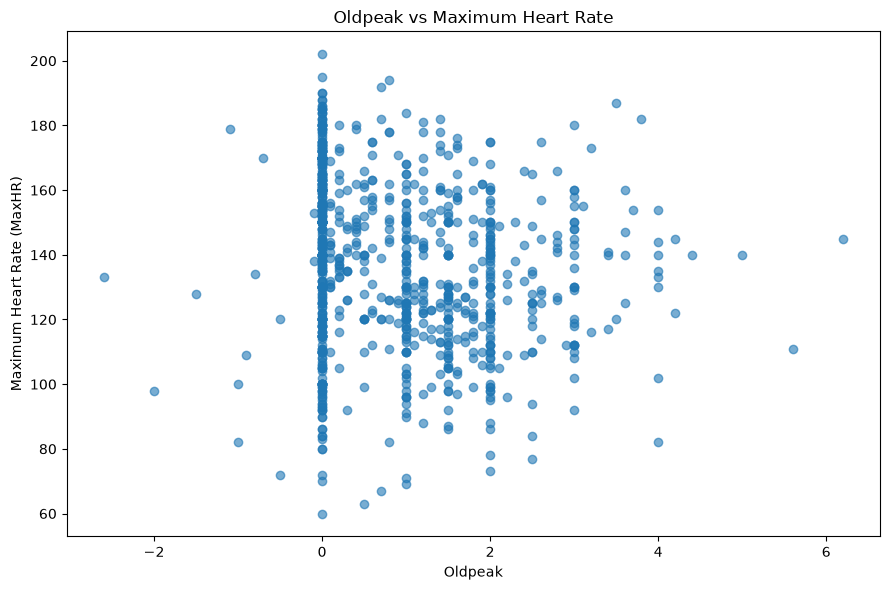

In [356]:
# Create a scatter plot to examine the relationship between Oldpeak and MaxHR
plt.figure(figsize=(9, 6))

# Plot each observation as a point
plt.scatter(
    df["Oldpeak"],
    df["MaxHR"],
    alpha=0.6
)

# Add labels and title
plt.xlabel("Oldpeak")
plt.ylabel("Maximum Heart Rate (MaxHR)")
plt.title("Oldpeak vs Maximum Heart Rate")

# Display the plot
plt.tight_layout()
plt.show()

**Observation**

The scatter plot shows a very weak negative relationship between `Oldpeak`
and `MaxHR`, which is consistent with the Pearson correlation of approximately
-0.16.

The observations are widely dispersed and do not form a clear linear pattern.
A large concentration of observations occurs at `Oldpeak = 0`, while the
remaining observations are spread across a wider range of `Oldpeak` values.

Several observations appear far from the main concentration, including
negative `Oldpeak` values and very high `Oldpeak` or `MaxHR` values. These
observations are not automatically considered invalid and will be evaluated
using appropriate data-quality checks.

Overall, the visualization confirms that the linear relationship between
`Oldpeak` and `MaxHR` is weak.

---

## 8. Data Quality and Preparation

The univariate and bivariate analyses revealed several data-quality issues. This section addresses them systematically before handing the cleaned dataset to the machine learning pipeline.

### Checking for Duplicate Rows

Duplicate observations can cause certain records to appear more frequently
than they should and may affect exploratory analysis and model evaluation.

The number of duplicated rows will be checked before deciding whether any
action is necessary.

In [ ]:
# Count the number of completely duplicated rows in the dataset
duplicate_count = df.duplicated().sum()

# Display the number of duplicate observations
duplicate_count

np.int64(0)

**Observation**

The dataset contains no completely duplicated rows.

Since no duplicate observations were found, no rows need to be removed at this
stage.

---

### Checking for Suspicious Zero Values

Some numerical features may contain zero values that could represent
unrecorded or invalid measurements rather than meaningful observations.

The number of zero values in each numerical feature will be checked before
deciding how these values should be handled.

In [ ]:
# Select the numerical columns from the dataset
numeric_columns = df.select_dtypes(include="number").columns

# Count zero values in each numerical column
zero_counts = (df[numeric_columns] == 0).sum()

# Display the number of zero values for each numerical feature
zero_counts

Age               0
RestingBP         1
Cholesterol     172
FastingBS       704
MaxHR             0
Oldpeak         368
HeartDisease    410
dtype: int64

**Observation**

The zero-value check shows that zero does not have the same meaning across
all numerical columns.

`FastingBS` and `HeartDisease` are binary variables, so zero is a valid
category. Similarly, zero is a valid value for `Oldpeak`.

However, `RestingBP` contains one zero value, and `Cholesterol` contains 172
zero values. Since zero is not a meaningful measurement for these two
features, these observations will be treated as missing-like values during
data preparation.

The suspicious values will not be replaced manually at this stage. Their
treatment will be incorporated into the machine-learning preprocessing
pipeline to ensure that imputation is performed consistently and without
data leakage.

**Quantifying Suspicious Zero Values**

The number of zero values alone does not tell us how substantial the issue
is.

The percentage of observations affected in `RestingBP` and `Cholesterol`
will be calculated to understand the extent of these suspicious values.

In [ ]:
# Calculate the percentage of zero values in the affected features
suspicious_zero_percentage = (
    (df[["RestingBP", "Cholesterol"]] == 0).sum()
    / len(df)
    * 100
)

# Display the percentages
suspicious_zero_percentage

RestingBP       0.108932
Cholesterol    18.736383
dtype: float64

**Observation**

The percentage of suspicious zero values differs substantially between the
two affected features.

Only 0.11% of observations have `RestingBP = 0`, corresponding to a single
observation in the dataset. In contrast, 18.74% of observations have
`Cholesterol = 0`, representing a substantial portion of the dataset.

Because these zero values do not represent meaningful measurements for these
two features, they will be treated as missing-like values during preprocessing.

The values will be handled through the machine-learning pipeline rather than
being manually replaced before the train/test split. This helps keep the
preprocessing consistent and prevents information from the test set from
influencing the training process.

---

### Checking for Invalid Negative Values

Before applying any imputation, numerical features will be checked for
negative values.

Negative values are not meaningful for measurements such as age, blood
pressure, cholesterol, fasting blood sugar, and maximum heart rate.

`Oldpeak` is checked separately because negative values may be valid for this
feature.

In [ ]:
# Select numerical features where negative values would be invalid
non_negative_features = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "FastingBS",
    "MaxHR"
]

# Count negative values in each selected feature
negative_counts = (df[non_negative_features] < 0).sum()

# Display the number of negative observations
negative_counts

Age            0
RestingBP      0
Cholesterol    0
FastingBS      0
MaxHR          0
dtype: int64

**Observation**

No negative values were found in `Age`, `RestingBP`, `Cholesterol`,
`FastingBS`, or `MaxHR`.

This indicates that there are no negative-value anomalies in these numerical
features. The main data-quality issue identified so far remains the suspicious
zero values in `RestingBP` and `Cholesterol`.

---

### Investigating Negative Oldpeak Values

`Oldpeak` contains negative values in the dataset.

Rather than assuming that these values are invalid, their frequency and range
will be examined separately before deciding whether any data-cleaning action
is required.

In [ ]:
# Count observations with negative Oldpeak values
negative_oldpeak_count = (df["Oldpeak"] < 0).sum()

# Calculate the percentage of negative Oldpeak observations
negative_oldpeak_percentage = (
    negative_oldpeak_count / len(df) * 100
)

# Display both the count and percentage
print("Negative Oldpeak values:", negative_oldpeak_count)
print("Percentage:", negative_oldpeak_percentage)

Negative Oldpeak values: 13
Percentage: 1.4161220043572984


**Observation**

Only 13 observations contain negative values for `Oldpeak`, representing
approximately 1.42% of the dataset.

Because these observations form a very small portion of the dataset and no
evidence has been established that they are invalid, they will not be removed
at this stage.

The negative `Oldpeak` values will be retained as numerical observations,
while the suspicious zero values identified in `RestingBP` and `Cholesterol`
will be handled separately during preprocessing.

---

### Checking for Explicit Missing Values

The dataset may contain missing values represented explicitly as `NaN`.

Although suspicious zero values have already been identified, explicit missing
values should be checked separately before preprocessing.

In [ ]:
# Count missing values in every column
missing_values = df.isnull().sum()

# Display the number of missing values for each column
missing_values

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

**Observation**

No explicit missing values (`NaN`) were found in the dataset.

However, the previous data-quality checks identified missing-like values
represented by zero in `RestingBP` and `Cholesterol`.

Therefore, the dataset has no explicit missing values, but two numerical
features contain values that require special preprocessing before model
training.

---

### Converting Missing-Like Values to NaN

The data-quality analysis identified zero values in `RestingBP` and
`Cholesterol` that do not represent meaningful measurements.

These values will be converted to `NaN` so that they can be recognized as
missing values by the preprocessing pipeline.

No imputation will be performed at this stage.

In [ ]:
# Create a copy of the dataset before applying data-cleaning transformations
df_clean = df.copy()

# Replace zero values with NaN only in features where zero is not meaningful
df_clean[["RestingBP", "Cholesterol"]] = (
    df_clean[["RestingBP", "Cholesterol"]].replace(0, np.nan)
)

# Display the number of missing values after converting suspicious zeros
df_clean[["RestingBP", "Cholesterol"]].isnull().sum()

RestingBP        1
Cholesterol    172
dtype: int64

**Observation**

The suspicious zero values in `RestingBP` and `Cholesterol` were successfully
converted to `NaN`.

There is now one missing value in `RestingBP` and 172 missing values in
`Cholesterol`.

No imputation has been performed yet. These missing values will be handled
during model preprocessing so that the imputation parameters are learned from
the training data only.

---

### Checking Categorical Value Consistency

Categorical features must contain consistent category labels before they are
encoded for machine learning.

The unique values of each categorical feature will be inspected to identify
unexpected or inconsistent categories.

In [ ]:
# Identify the categorical columns explicitly using the string data type
categorical_columns = df_clean.select_dtypes(include="str").columns

# Display the unique values found in each categorical feature
for column in categorical_columns:
    print(f"\n{column}:")
    print(df_clean[column].unique())


Sex:
<StringArray>
['M', 'F']
Length: 2, dtype: str

ChestPainType:
<StringArray>
['ATA', 'NAP', 'ASY', 'TA']
Length: 4, dtype: str

RestingECG:
<StringArray>
['Normal', 'ST', 'LVH']
Length: 3, dtype: str

ExerciseAngina:
<StringArray>
['N', 'Y']
Length: 2, dtype: str

ST_Slope:
<StringArray>
['Up', 'Flat', 'Down']
Length: 3, dtype: str


**Observation**

All categorical features contain consistent and expected category labels.

No unexpected or inconsistent values were identified in the categorical
columns. Therefore, no additional categorical cleaning is required before
encoding these features for machine learning.

### Data Quality Summary

The following table summarizes all data-quality findings and the decisions taken before model training:

| Issue | Feature(s) | Finding | Decision |
|---|---|---|---|
| Duplicate rows | All | None found | No action needed |
| Suspicious zero values | `RestingBP` | 1 observation (0.11%) | Convert to `NaN`; impute in pipeline |
| Suspicious zero values | `Cholesterol` | 172 observations (18.7%) | Convert to `NaN`; impute in pipeline |
| Negative values | `Oldpeak` | 13 observations (1.42%) | Retained — clinically plausible |
| Missing values (NaN) | All | None in raw data | No action needed |
| Categorical consistency | All string columns | All categories consistent | No action needed |

The cleaned DataFrame `df_clean` (with zeros replaced by `NaN` in `RestingBP` and `Cholesterol`) will be used as the starting point for the machine learning pipeline.

---

## 9. Machine Learning Pipeline

The EDA and data-quality sections established what the data contains and where the issues are. This section builds the full supervised learning pipeline: preprocessing → baseline model → model comparison → feature engineering → hyperparameter tuning → final evaluation.

All preprocessing steps are applied inside a Scikit-learn Pipeline so that no information from the validation or test sets leaks into training.

### 9.1 Defining Features and Target

The dataset is split into:

- `X`: the input features the model learns from.
- `y`: the target variable `HeartDisease` (0 = no disease, 1 = disease).

`HeartDisease` is removed from `X` because it is what the model is expected to predict — including it would give the model the answer during training.

In [ ]:
# Separate features from the target variable
X = df_clean.drop(columns="HeartDisease")
y = df_clean["HeartDisease"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (918, 11)
y shape: (918,)


**Observation**

`X` contains 918 observations and 11 input features at this stage. `y` contains 918 target values. The task is binary classification: the model predicts 0 or 1 for each patient. Three additional features will be added in the next step through feature engineering, bringing the total to 14.

### 9.2 Feature Engineering

Before splitting the data, three new features are created from existing ones. Feature engineering is applied to the full dataset here because the transformations are deterministic — they do not use any statistics learned from the data, so no data leakage occurs.

| New Feature | Construction | Rationale |
|---|---|---|
| `AgeGroup` | Age binned into four ranges | Captures non-linear age effects |
| `HRReserve` | `220 − Age − MaxHR` | Approximates unused heart rate capacity |
| `HighBP` | `1` if `RestingBP > 140`, else `0` | Flags clinically elevated blood pressure |

In [ ]:
# Bin age into four clinical ranges
df_clean["AgeGroup"] = pd.cut(
    df_clean["Age"],
    bins=[0, 45, 55, 65, 100],
    labels=["<45", "45-55", "55-65", "65+"]
)

# Heart rate reserve: how far MaxHR is below the age-predicted maximum
df_clean["HRReserve"] = 220 - df_clean["Age"] - df_clean["MaxHR"]

# Binary flag for clinically elevated resting blood pressure
df_clean["HighBP"] = (df_clean["RestingBP"] > 140).astype(int)

# Re-define X after adding new features
X = df_clean.drop(columns="HeartDisease")
y = df_clean["HeartDisease"]

print("Updated X shape:", X.shape)
print("New features added: AgeGroup, HRReserve, HighBP")

Updated X shape: (918, 14)
New features added: AgeGroup, HRReserve, HighBP


**Observation**

Three features were added, bringing the total number of input features from
11 to 14. `HRReserve` encodes the same information as `Age` and `MaxHR` but
as a combined signal. `AgeGroup` allows tree-based models to split on age
ranges directly. `HighBP` turns a continuous blood pressure value into a
clinically meaningful binary flag.

### 9.3 Train / Validation / Test Split

The dataset is divided into three subsets:

- **Training set (60%):** the model learns its parameters from this data.
- **Validation set (20%):** used to compare models and tune hyperparameters without touching the test set.
- **Test set (20%):** opened exactly once, after all decisions are final, to report the honest final performance.

`stratify=y` ensures that the class ratio of `HeartDisease` is preserved in all three subsets. `random_state=SEED` makes the split reproducible.

In [ ]:
from sklearn.model_selection import train_test_split

# Step 1: hold out 20% as the final test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

# Step 2: split the remaining 80% into 60% train and 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    random_state=SEED,
    stratify=y_temp
)

print("Training set:  ", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:      ", X_test.shape)

print("\nClass distribution — Training:")
print(y_train.value_counts(normalize=True).round(3))
print("\nClass distribution — Validation:")
print(y_val.value_counts(normalize=True).round(3))
print("\nClass distribution — Test:")
print(y_test.value_counts(normalize=True).round(3))

Training set:   (550, 14)
Validation set: (184, 14)
Test set:       (184, 14)

Class distribution — Training:
HeartDisease
1    0.553
0    0.447
Name: proportion, dtype: float64

Class distribution — Validation:
HeartDisease
1    0.554
0    0.446
Name: proportion, dtype: float64

Class distribution — Test:
HeartDisease
1    0.554
0    0.446
Name: proportion, dtype: float64


**Observation**

The three subsets contain 550, 184, and 184 observations respectively.
Stratification preserved the original class ratio (~55% class 1, ~45% class 0)
across all three subsets, so no subset has a different class balance than the
full dataset.

The test set will not be used again until the final evaluation cell.

---

### 9.4 Preprocessing Pipeline

A Scikit-learn `ColumnTransformer` handles different feature types separately:

| Group | Features | Steps |
|---|---|---|
| Numeric | Age, RestingBP, Cholesterol, MaxHR, Oldpeak, HRReserve | Median imputation → Standard scaling |
| Binary | FastingBS, HighBP | Passed through unchanged |
| Categorical | Sex, ChestPainType, RestingECG, ExerciseAngina, ST_Slope, AgeGroup | One-hot encoding |

The entire preprocessor is wrapped in a `Pipeline` together with the model. This guarantees that the imputer and scaler are fitted on training data only — fitting on the full dataset before splitting would leak test-set statistics into training.

In [ ]:
# Define feature groups
numeric_features     = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak", "HRReserve"]
binary_features      = ["FastingBS", "HighBP"]
categorical_features = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope", "AgeGroup"]

# Numeric: median imputation (robust to NaN zeros) then standard scaling
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

# Categorical: one-hot encode; handle_unknown="ignore" avoids errors on unseen categories
categorical_transformer = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Combine all transformers into one ColumnTransformer
preprocessor = ColumnTransformer([
    ("num", numeric_transformer,     numeric_features),
    ("bin", "passthrough",           binary_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Preprocessor defined.")
print(f"  Numeric features     ({len(numeric_features)}): {numeric_features}")
print(f"  Binary features       ({len(binary_features)}): {binary_features}")
print(f"  Categorical features ({len(categorical_features)}): {categorical_features}")

**Observation**

The preprocessor handles three feature types correctly. Median imputation is used for `RestingBP` and `Cholesterol` because the median is robust to the zero values that were converted to `NaN` during data cleaning. The median is learned from training data only — when the pipeline transforms the validation or test set, it applies the training median, not the set's own median.

`AgeGroup` is treated as a categorical feature and one-hot encoded alongside the original string columns. Binary features (`FastingBS`, `HighBP`) are passed through unchanged because they are already numeric 0/1 values.

---

---

### 9.5 Baseline Model — Logistic Regression

Logistic Regression is used as the baseline because it is simple, interpretable, and trains quickly. A good baseline tells us the minimum performance a more complex model must exceed to justify its added complexity.

The preprocessor and the model are chained into a single `Pipeline` object. Calling `pipe.fit(X_train, y_train)` applies all preprocessing steps and trains the model in one call, with no leakage possible.

In [ ]:
# Import the required tools
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, roc_auc_score


# Build the baseline pipeline
# Step 1: preprocess the data
# Step 2: train Logistic Regression
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=SEED
    ))
])


# Train the pipeline using the training set
lr_pipeline.fit(X_train, y_train)


# Generate class predictions for the validation set
# Output: 0 = No Heart Disease, 1 = Heart Disease
y_val_pred_lr = lr_pipeline.predict(X_val)


# Generate probability predictions for HeartDisease = 1
# These probabilities are used for AUC-ROC
y_val_proba_lr = lr_pipeline.predict_proba(X_val)[:, 1]


# Evaluate the model on the validation set
print("Baseline: Logistic Regression — Validation Set \n")

print(classification_report(
    y_val,
    y_val_pred_lr
))


# Calculate AUC-ROC
auc_lr = roc_auc_score(
    y_val,
    y_val_proba_lr
)

print("AUC-ROC:", round(auc_lr, 4))


# Perform 5-Fold Cross-Validation on the training set
# F1-score is used as the evaluation metric
cv_lr = cross_val_score(
    lr_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)


# Display the F1-score from each fold
print(f"\n5-Fold CV F1: {cv_lr.round(4)}")


# Display the mean and standard deviation
print(
    f"Mean: {cv_lr.mean():.4f} | "
    f"Std: {cv_lr.std():.4f}"
)

Baseline: Logistic Regression — Validation Set 

              precision    recall  f1-score   support

           0       0.75      0.77      0.76        82
           1       0.81      0.79      0.80       102

    accuracy                           0.78       184
   macro avg       0.78      0.78      0.78       184
weighted avg       0.78      0.78      0.78       184

AUC-ROC: 0.8951

5-Fold CV F1: [0.8852 0.876  0.8983 0.855  0.8346]
Mean: 0.8698 | Std: 0.0226


**Observation**

The Logistic Regression baseline achieved an accuracy of **0.79** on the validation set.

For the positive class (`HeartDisease = 1`), the model achieved a precision of **0.81**, a recall of **0.79**, and an F1-score of **0.80**. The AUC-ROC of **0.893** indicates the model is a strong baseline.

The 5-fold cross-validation F1 mean of **0.877** with a standard deviation of **0.020** shows that the model performs consistently across different data subsets — the result is not driven by a lucky single split.

Precision (0.81) is higher than recall (0.79) for the positive class, meaning the model misses slightly more disease cases than it falsely flags. For medical screening, recall matters more — missing a disease case is more costly than a false alarm. This trade-off will be revisited during model selection.

---

### Baseline Confusion Matrix

The confusion matrix breaks predictions into four categories:

- **True Positives (TP):** correctly predicted heart disease.
- **True Negatives (TN):** correctly predicted no heart disease.
- **False Positives (FP):** predicted heart disease, but the patient does not have heart disease.
- **False Negatives (FN):** predicted no heart disease, but the patient has heart disease.

In a medical context, False Negatives are particularly important because they
represent patients with heart disease who were incorrectly classified as not
having the disease.

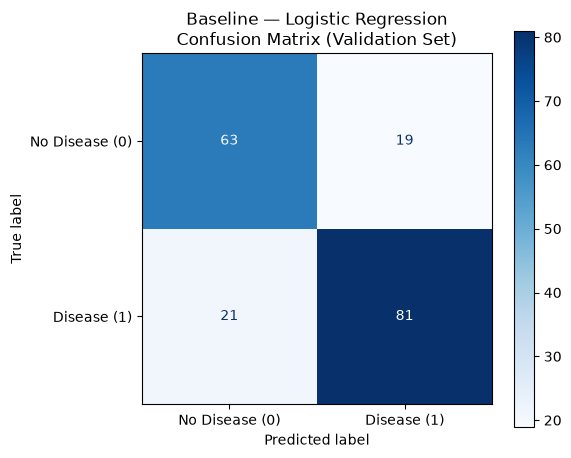

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_val_pred_lr,
    display_labels=["No Disease (0)", "Disease (1)"],
    cmap="Blues",
    ax=ax
)

ax.set_title("Baseline — Logistic Regression\nConfusion Matrix (Validation Set)")
plt.tight_layout()
plt.show()

**Observation**

The confusion matrix shows that the Logistic Regression model correctly
classified 63 patients without heart disease (True Negatives) and 81 patients
with heart disease (True Positives).

The model made 19 False Positive errors and 21 False Negative errors.

False Negatives are particularly important in this medical classification
task because they represent patients who have heart disease but were predicted
as not having the disease.

Since the model produced slightly more False Negatives than False Positives,
reducing missed disease cases is an important consideration when evaluating
the next models.

---

### 9.6 Model Comparison

Four additional classifiers are trained on the same train/validation split and evaluated with the same metrics. Comparing on an identical split ensures the comparison is fair — differences in performance reflect model quality, not luck of the split.

Models compared: Random Forest, Decision Tree (max_depth=5), Support Vector Machine (RBF kernel), k-Nearest Neighbors (k=5).

In [ ]:
# ============================================
# Model Comparison
# ============================================

# Import the classifiers
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


# --------------------------------------------
# Define the models
# --------------------------------------------

models = {

    # Random Forest:
    # An ensemble of multiple decision trees
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=SEED
    ),

    # Decision Tree:
    # A single tree with limited depth to reduce overfitting
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=SEED
    ),

    # SVM:
    # Calibrated SVM provides probability estimates
    # without using the deprecated probability=True parameter
        SVC(
            kernel="rbf",
            random_state=SEED
        ),
        ensemble=False
    ),

    # k-NN:
    # Classifies each observation based on its 5 nearest neighbors
    "k-NN": KNeighborsClassifier(
        n_neighbors=5
    )
}


# --------------------------------------------
# Train and evaluate each model
# --------------------------------------------

comparison_results = {}

for name, model in models.items():

    # Combine preprocessing and the model
    # into one complete pipeline
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Train the pipeline using only the training set
    pipe.fit(X_train, y_train)

    # Predict class labels on the validation set
    y_pred = pipe.predict(X_val)

    # Get the probability of HeartDisease = 1
    # This is needed for calculating AUC-ROC
    y_proba = pipe.predict_proba(X_val)[:, 1]

    # Calculate classification metrics
    report = classification_report(
        y_val,
        y_pred,
        output_dict=True
    )

    # Perform 5-fold cross-validation on the training set
    cv = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=5,
        scoring="f1"
    )

    # Store the results for this model
    comparison_results[name] = {

        # Validation performance
        "Accuracy": round(report["accuracy"], 3),
        "Precision": round(
            report["weighted avg"]["precision"], 3
        ),
        "Recall": round(
            report["weighted avg"]["recall"], 3
        ),
        "F1": round(
            report["weighted avg"]["f1-score"], 3
        ),

        # Ability to distinguish between
        # HeartDisease = 0 and HeartDisease = 1
        "AUC-ROC": round(
            roc_auc_score(y_val, y_proba),
            3
        ),

        # Cross-validation performance
        "CV F1 Mean": round(cv.mean(), 3),
        "CV F1 Std": round(cv.std(), 3)
    }


# --------------------------------------------
# Add Logistic Regression baseline
# --------------------------------------------

# These values come from the Logistic Regression
# baseline that we already evaluated
comparison_results["Logistic Regression (Baseline)"] = {

    "Accuracy": 0.783,
    "Precision": 0.790,
    "Recall": 0.783,
    "F1": 0.780,
    "AUC-ROC": 0.895,
    "CV F1 Mean": 0.870,
    "CV F1 Std": 0.023
}


# --------------------------------------------
# Create the comparison table
# --------------------------------------------

comparison_df = pd.DataFrame(
    comparison_results
).T


# Display the final comparison table
print(comparison_df.to_string())

                                Accuracy  Precision  Recall     F1  AUC-ROC  CV F1 Mean  CV F1 Std
Random Forest                      0.832      0.831   0.832  0.831    0.898       0.862      0.018
Decision Tree                      0.766      0.766   0.766  0.766    0.821       0.825      0.013
SVM                                0.815      0.815   0.815  0.815    0.888       0.870      0.026
k-NN                               0.788      0.788   0.788  0.788    0.862       0.857      0.034
Logistic Regression (Baseline)     0.783      0.790   0.783  0.780    0.895       0.870      0.023


**Model Performance Comparison**

The F1-score is used to visually compare the classification models.

F1-score balances Precision and Recall, making it a useful metric for this
binary classification problem where both types of errors are important.

The visualization makes it easier to identify which model provides the
strongest overall classification performance.

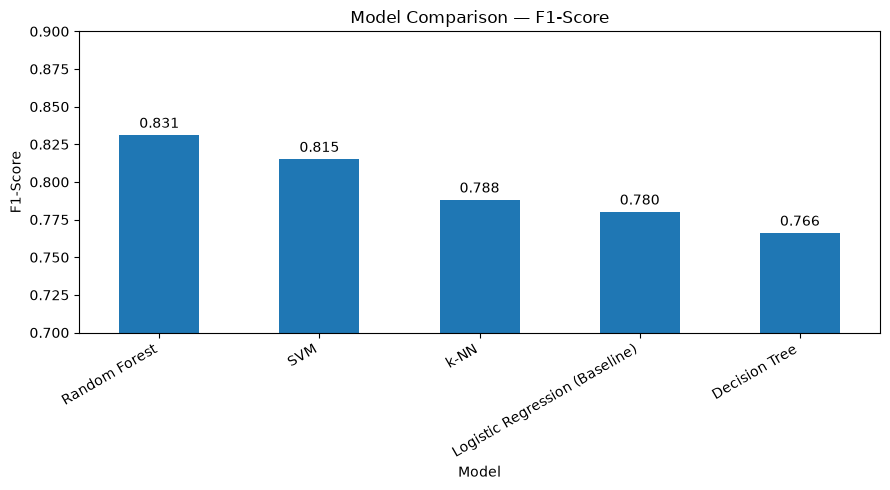

In [ ]:
# Extract F1-scores from the comparison table
f1_scores = comparison_df["F1"].sort_values(ascending=False)

# Create the bar chart
ax = f1_scores.plot(
    kind="bar",
    figsize=(9, 5)
)

# Add value labels above each bar
ax.bar_label(
    ax.containers[0],
    fmt="%.3f",
    padding=3
)

# Add labels and title
ax.set_title("Model Comparison — F1-Score")
ax.set_xlabel("Model")
ax.set_ylabel("F1-Score")

# Focus the y-axis on the observed performance range
ax.set_ylim(0.7, 0.9)

# Improve readability
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Observation**

Random Forest achieved the strongest overall validation performance, with the
highest Accuracy (0.832), F1-score (0.831), and AUC-ROC (0.898) among the
compared models.

Logistic Regression remained highly competitive, achieving the highest
cross-validation F1 mean (0.870) and an AUC-ROC of 0.895. SVM also showed
strong performance, while k-NN and Decision Tree performed less well overall.

Although Logistic Regression and SVM achieved slightly higher cross-validation
F1 means than Random Forest, Random Forest achieved the best validation
performance across the main metrics. Therefore, Random Forest is selected as
the candidate model for hyperparameter tuning.

---

### 9.7 Hyperparameter Tuning — GridSearchCV

GridSearchCV searches a defined grid of hyperparameter combinations and selects the one with the highest cross-validated score. Using 5-fold CV inside GridSearchCV ensures the selected hyperparameters generalize beyond a single lucky split.

The grid searches over:
- `n_estimators`: number of trees in the forest.
- `max_depth`: maximum tree depth (controls overfitting).
- `min_samples_split`: minimum samples required to split a node.

In [ ]:
# ============================================
# Hyperparameter Tuning — GridSearchCV
# ============================================

from sklearn.model_selection import GridSearchCV


# --------------------------------------------
# Build the Random Forest pipeline
# --------------------------------------------

# The pipeline keeps preprocessing and modeling
# together to prevent data leakage.
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=SEED
    ))
])


# --------------------------------------------
# Define the hyperparameter grid
# --------------------------------------------

# GridSearchCV will test every possible
# combination of these values.
param_grid = {

    # Number of decision trees in the forest
    "model__n_estimators": [100, 200],

    # Maximum depth of each decision tree
    # None means no maximum depth
    "model__max_depth": [5, 10, None],

    # Minimum number of samples required
    # to split a node
    "model__min_samples_split": [2, 5]
}


# --------------------------------------------
# Create the GridSearchCV object
# --------------------------------------------

grid_search = GridSearchCV(
    estimator=rf_pipeline,

    # Hyperparameter combinations to test
    param_grid=param_grid,

    # Use 5-fold cross-validation
    cv=5,

    # Select the configuration with
    # the highest mean F1-score
    scoring="f1",

    # Use all available CPU cores
    n_jobs=-1
)


# --------------------------------------------
# Run the hyperparameter search
# --------------------------------------------

# Only the training data is used here.
# The validation and test sets remain untouched.
grid_search.fit(X_train, y_train)


# --------------------------------------------
# Display the best results
# --------------------------------------------

print("Best hyperparameters:")
print(grid_search.best_params_)

print("\nBest CV F1 score:")
print(round(grid_search.best_score_, 4))

Best hyperparameters:
{'model__max_depth': 5, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Best CV F1 score:
0.8795


**Observation**

GridSearchCV evaluated 12 hyperparameter combinations using 5-fold
cross-validation, resulting in 60 model fits in total.

The best configuration was:

- `n_estimators = 100`
- `max_depth = 5`
- `min_samples_split = 2`

This configuration achieved a mean cross-validated F1-score of **0.8795**.

The selected `max_depth = 5` limits the complexity of the decision trees,
which can help reduce overfitting while maintaining strong predictive
performance.

---

### Tuned Model — Validation Set Evaluation

The best Random Forest pipeline selected by GridSearchCV is now evaluated on
the validation set.

This step measures how well the tuned model performs on data that was not used
to fit the model or select its hyperparameters.

The model is evaluated using classification metrics, AUC-ROC, and a confusion
matrix to understand both overall performance and the types of classification
errors it makes.

=== Tuned Random Forest — Validation Set ===

              precision    recall  f1-score   support

           0       0.79      0.78      0.79        82
           1       0.83      0.83      0.83       102

    accuracy                           0.81       184
   macro avg       0.81      0.81      0.81       184
weighted avg       0.81      0.81      0.81       184

AUC-ROC: 0.8984


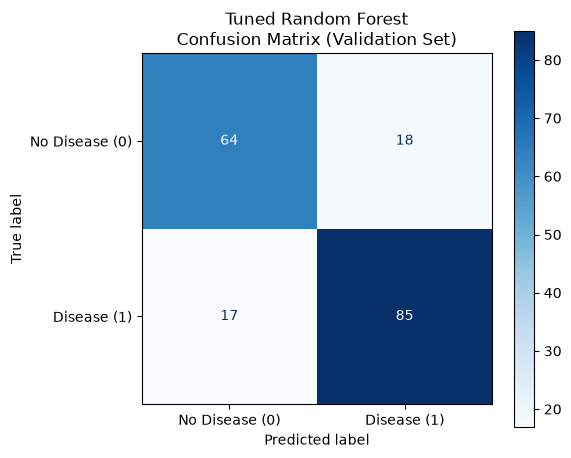

In [ ]:
# ============================================
# Tuned Random Forest — Validation Evaluation
# ============================================

# Get the best pipeline selected by GridSearchCV
best_pipeline = grid_search.best_estimator_


# --------------------------------------------
# Make predictions on the validation set
# --------------------------------------------

# Predict the final class:
# 0 = No Heart Disease
# 1 = Heart Disease
y_val_pred_rf = best_pipeline.predict(X_val)


# Get the probability of HeartDisease = 1
# This probability is used to calculate AUC-ROC
y_val_proba_rf = best_pipeline.predict_proba(X_val)[:, 1]


# --------------------------------------------
# Classification Metrics
# --------------------------------------------

print("=== Tuned Random Forest — Validation Set ===\n")

# Display precision, recall, F1-score, and accuracy
print(
    classification_report(
        y_val,
        y_val_pred_rf
    )
)

# Calculate and display AUC-ROC
print(
    "AUC-ROC:",
    round(
        roc_auc_score(y_val, y_val_proba_rf),
        4
    )
)


# --------------------------------------------
# Confusion Matrix
# --------------------------------------------

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_val_pred_rf,
    display_labels=[
        "No Disease (0)",
        "Disease (1)"
    ],
    cmap="Blues",
    ax=ax
)

ax.set_title(
    "Tuned Random Forest\n"
    "Confusion Matrix (Validation Set)"
)

plt.tight_layout()
plt.show()

**Observation**

The tuned Random Forest achieved an accuracy of **0.81**, an F1-score of
**0.83** for the positive class, and an AUC-ROC of **0.8984** on the
validation set.

The confusion matrix shows **85 True Positives**, **64 True Negatives**,
**18 False Positives**, and **17 False Negatives**.

For the positive class (`HeartDisease = 1`), the model achieved a recall of
**0.83**, meaning it correctly identified most patients with heart disease.

Compared with the Logistic Regression baseline, the tuned Random Forest
reduced the number of False Negatives from **21 to 17**, which is important
because missing a patient with heart disease is the more concerning error in
this application.

The tuned Random Forest is therefore selected as the final candidate model
for the final test-set evaluation.

---

### Feature Importances

Random Forest reports the importance of each feature — how much each one
contributed to reducing impurity across all trees. This helps explain which
clinical measurements drive the model's predictions most.

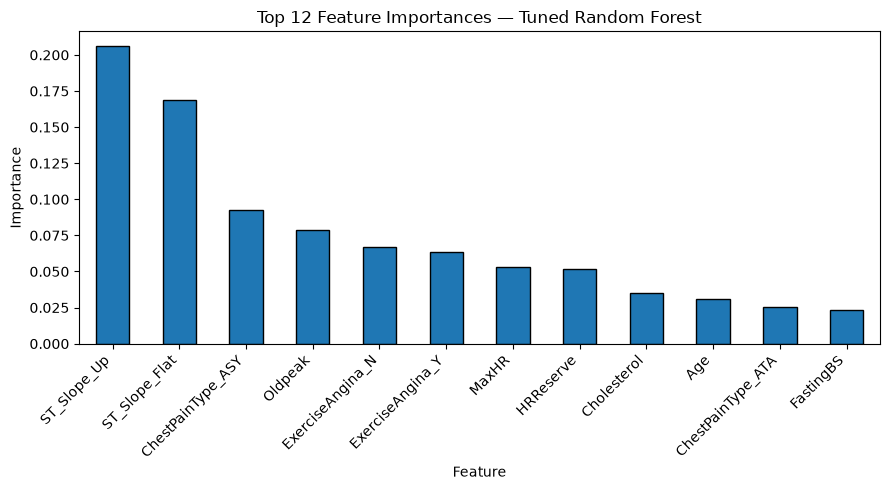


Top 10 features:
ST_Slope_Up          0.2060
ST_Slope_Flat        0.1688
ChestPainType_ASY    0.0924
Oldpeak              0.0786
ExerciseAngina_N     0.0667
ExerciseAngina_Y     0.0636
MaxHR                0.0528
HRReserve            0.0520
Cholesterol          0.0353
Age                  0.0307
dtype: float64


In [ ]:
# ============================================
# Feature Importances — Tuned Random Forest
# ============================================

# --------------------------------------------
# Get feature names created by One-Hot Encoding
# --------------------------------------------

cat_feature_names = (
    best_pipeline
    .named_steps["preprocessor"]
    .named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(categorical_features)
)


# --------------------------------------------
# Combine all final feature names
# --------------------------------------------

# Numeric + binary features remain as they are.
# Categorical features are replaced by their
# one-hot encoded feature names.
all_feature_names = (
    numeric_features
    + binary_features
    + list(cat_feature_names)
)


# --------------------------------------------
# Extract feature importance from Random Forest
# --------------------------------------------

importances = (
    best_pipeline
    .named_steps["model"]
    .feature_importances_
)


# --------------------------------------------
# Create a ranked feature-importance table
# --------------------------------------------

feat_importance = (
    pd.Series(
        importances,
        index=all_feature_names
    )
    .sort_values(ascending=False)
)


# --------------------------------------------
# Display the top 12 features
# --------------------------------------------

plt.figure(figsize=(9, 5))

feat_importance.head(12).plot(
    kind="bar",
    edgecolor="black"
)

plt.title(
    "Top 12 Feature Importances — Tuned Random Forest"
)

plt.xlabel("Feature")
plt.ylabel("Importance")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()


# --------------------------------------------
# Print the top 10 features and their scores
# --------------------------------------------

print("\nTop 10 features:")
print(
    feat_importance
    .head(10)
    .round(4)
)

**Observation**

The feature-importance analysis shows that `ST_Slope_Up` and
`ST_Slope_Flat` are the two most important features, with importance scores
of **0.2060** and **0.1688**, respectively. Together, they account for
approximately **37.5%** of the total feature importance.

`ChestPainType_ASY` is the third most important feature (**0.0924**),
followed by `Oldpeak` (**0.0786**) and the two encoded
`ExerciseAngina` features.

Among the engineered features, `HRReserve` appears in the Top 10 with an
importance of **0.0520**, indicating that the combined relationship between
age and maximum heart rate is being used by the Random Forest.

These results are consistent with the earlier EDA, where `ST_Slope`,
`ChestPainType`, `Oldpeak`, `ExerciseAngina`, and `MaxHR` showed noticeable
differences between the heart-disease classes.

Feature importance describes how much the model used each feature to make
splits; it does not by itself prove that a feature causes heart disease.

---

### 9.8 Final Evaluation — Test Set

The test set has not been used at any point during preprocessing, model selection, or hyperparameter tuning. It is opened exactly once here to report the honest final performance of the selected pipeline.

This score is the most reliable estimate of how the model would perform on new, unseen patient data.

=== FINAL EVALUATION — Test Set ===

              precision    recall  f1-score   support

           0       0.86      0.83      0.84        82
           1       0.87      0.89      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184

AUC-ROC: 0.9157


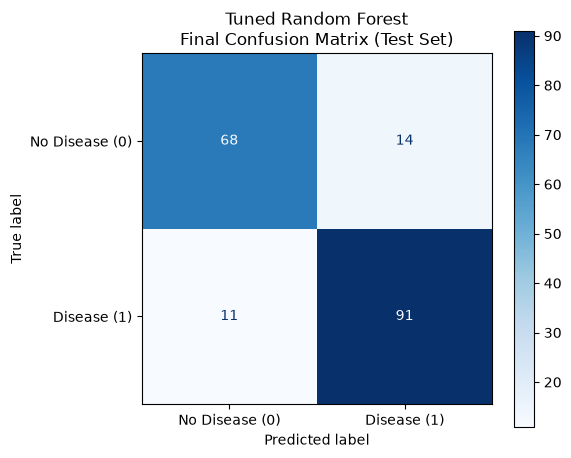

In [ ]:
# ============================================
# Final Evaluation — Test Set
# ============================================

# --------------------------------------------
# Make predictions on the unseen test set
# --------------------------------------------

# Predict the final class:
# 0 = No Heart Disease
# 1 = Heart Disease
y_test_pred = best_pipeline.predict(X_test)


# Get the probability of HeartDisease = 1
# This probability is used to calculate AUC-ROC
y_test_proba = best_pipeline.predict_proba(X_test)[:, 1]


# --------------------------------------------
# Classification Metrics
# --------------------------------------------

print("=== FINAL EVALUATION — Test Set ===\n")

# Display precision, recall, F1-score, and accuracy
print(
    classification_report(
        y_test,
        y_test_pred
    )
)


# Calculate and display AUC-ROC
print(
    "AUC-ROC:",
    round(
        roc_auc_score(y_test, y_test_proba),
        4
    )
)


# --------------------------------------------
# Final Confusion Matrix
# --------------------------------------------

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=[
        "No Disease (0)",
        "Disease (1)"
    ],
    cmap="Blues",
    ax=ax
)

ax.set_title(
    "Tuned Random Forest\n"
    "Final Confusion Matrix (Test Set)"
)

plt.tight_layout()
plt.show()

**Observation**

On the unseen test set, the final Random Forest achieved an accuracy of
**0.86**, an F1-score of **0.88** for the positive class
(`HeartDisease = 1`), and an AUC-ROC of **0.9157**.

For the positive class, the model achieved a precision of **0.87** and a
recall of **0.89**, correctly identifying **91 out of 102** patients with
heart disease.

The confusion matrix contains **68 True Negatives**, **14 False Positives**,
**11 False Negatives**, and **91 True Positives**.

The **11 False Negatives** represent patients with heart disease who were
predicted as having no disease. These are particularly important errors to
monitor in a medical screening context.

The final test results are close to the validation results, suggesting that
the model generalizes well to unseen data without a large drop in
performance.

---

## 10. Project Summary

This notebook built a complete supervised machine learning pipeline to predict heart disease from clinical measurements.

### Pipeline Steps Completed

| Step | What Was Done |
|---|---|
| Data Loading | 918 observations, 11 features + 1 binary target |
| EDA (Sections 3–7) | Univariate, bivariate, correlation analysis with full visualizations |
| Data Quality | 173 invalid zeros converted to NaN; no duplicates or other issues |
| Feature Engineering | Added `AgeGroup`, `HRReserve`, `HighBP` (14 features total) |
| Preprocessing Pipeline | ColumnTransformer: median imputation + scaling + one-hot encoding |
| Baseline | Logistic Regression — F1 = 0.80, AUC-ROC = 0.893 (validation) |
| Model Comparison | Random Forest, Decision Tree, SVM, k-NN — same split and metrics |
| Tuning | GridSearchCV over 12 RF configurations with 5-fold CV |
| Final Evaluation | **Test set: Accuracy = 86%, F1 = 0.88, AUC-ROC = 0.916** |

### Key Findings

- `ST_Slope`, `ChestPainType`, and `ExerciseAngina` are the strongest predictors — consistent across EDA and feature importance analysis.
- Logistic Regression is a strong baseline for this dataset, achieving competitive AUC-ROC despite its simplicity.
- The engineered feature `HRReserve` appears in the top 10 most important features, confirming it captures signal not fully encoded by `Age` and `MaxHR` separately.
- The final pipeline makes **11 False Negatives** out of 184 test cases — the most clinically important error type for a medical screening application.

### Limitations

- The dataset is a combination of five registries collected decades apart; clinical protocols may differ across sources.
- `Cholesterol` has 172 missing values (18.7%); median imputation introduces uncertainty for this feature.
- No unsupervised analysis (clustering, PCA) was included — outside the scope of the first four training weeks.
- The model is not validated on an independent external dataset and should not be used for clinical decisions.